# GSE50760 Real Dataset pyGAGE Walkthrough
## Goal

This notebook is the next step after my controlled pyGAGE test.

The controlled notebook helped me understand the basic pyGAGE workflow. Now I want to move into a real public RNA seq dataset and make the workflow more useful for someone following along.

I am starting with GSE50760 because it includes normal colon, primary colorectal cancer, and liver metastasis samples. That gives the analysis a real biological progression structure.

For this first version, I am not trying to make a huge claim yet. I am first trying to make sure I can load the data, understand the sample groups, format the expression matrix correctly, and run pyGAGE in a clean way.



```
expression_matrix = expression_matrix.merge(sample_df, on="gene_id", how="outer")
```
was creating problems
the dataset is not too big. The merge method is the problem.





In [1]:
!pip install -q GEOparse pandas numpy polars matplotlib seaborn scipy pygage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.2 MB/s eta 0:00:00


In [ ]:
# This should have no installation issues since pygage is easy to install + all the same libraries from last time are being used! Execpt geoparse is new for out GEO dataset

In [ ]:
#Setup note to add

#Everything - initially is being ran in colab because it is easier to test the workflow here first. Once the notebook is cleaner, I can move it into VSCode with the README and project folders so it is easier to push to GitHub later.

In [2]:
from pathlib import Path
import urllib.request

import GEOparse
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from pygage.core import GAGEPreparation, GAGEAnalysis

base_dir = Path("gse50760_pygage")
raw_dir = base_dir / "data" / "raw"
processed_dir = base_dir / "data" / "processed"
results_dir = base_dir / "results"

for folder in [raw_dir, processed_dir, results_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready")
print("Raw data folder:", raw_dir)
print("Processed data folder:", processed_dir)
print("Results folder:", results_dir)

Project folders are ready
Raw data folder: gse50760_pygage/data/raw
Processed data folder: gse50760_pygage/data/processed
Results folder: gse50760_pygage/results


## Folder note

I am setting up the folder structure early because I want this notebook to eventually turn into something clean enough for GitHub.

The main idea is to keep raw files, processed files, and results separate. That way, the workflow is easier to follow and easier to reproduce later.

In [3]:
gse = GEOparse.get_GEO(
    geo="GSE50760",
    destdir=str(raw_dir),
    annotate_gpl=False
)

print("GEO series loaded")
print("Number of samples:", len(gse.gsms))

22-May-2026 08:27:41 DEBUG utils - Directory gse50760_pygage/data/raw already exists. Skipping.
DEBUG:GEOparse:Directory gse50760_pygage/data/raw already exists. Skipping.
22-May-2026 08:27:41 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/soft/GSE50760_family.soft.gz to gse50760_pygage/data/raw/GSE50760_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/soft/GSE50760_family.soft.gz to gse50760_pygage/data/raw/GSE50760_family.soft.gz
100%|██████████| 5.83k/5.83k [00:00<00:00, 73.8kB/s]
22-May-2026 08:27:41 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
22-May-2026 08:27:41 DEBUG downloader - Moving /tmp/tmpenikhi64 to /content/gse50760_pygage/data/raw/GSE50760_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpenikhi64 to /content/gse50760_pygage/data/raw/GSE50760_family.soft.gz
22-May-2026 08:27:41 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/serie

GEO series loaded
Number of samples: 54


## GEO metadata note

This worked. GEOparse downloaded and parsed the GSE50760 metadata file.

The output looks long because GEOparse prints each sample as it reads it, but the important part is that the GEO series loaded successfully. This gives me access to the sample metadata, which I need before building the expression matrix.

Next, I want to turn the sample metadata into a table so I can see which samples are normal colon, primary colorectal cancer, and liver metastasis.

In [4]:
sample_rows = []

for gsm_id, gsm in gse.gsms.items():
    title = gsm.metadata.get("title", [""])[0]
    source_name = gsm.metadata.get("source_name_ch1", [""])[0]
    characteristics = gsm.metadata.get("characteristics_ch1", [])
    supplementary_files = gsm.metadata.get("supplementary_file", [])

    sample_rows.append({
        "gsm_id": gsm_id,
        "title": title,
        "source_name": source_name,
        "characteristics": " | ".join(characteristics),
        "supplementary_files": " | ".join(supplementary_files)
    })

metadata = pd.DataFrame(sample_rows)

pd.set_option("display.max_colwidth", 250)
display(metadata.head(10))
print("Metadata shape:", metadata.shape)

,gsm_id,title,source_name,characteristics,supplementary_files
0,GSM1228184,primary colorectal cancer AMC_2-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
1,GSM1228185,primary colorectal cancer AMC_3-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
2,GSM1228186,primary colorectal cancer AMC_5-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
3,GSM1228187,primary colorectal cancer AMC_6-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
4,GSM1228188,primary colorectal cancer AMC_7-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
5,GSM1228189,primary colorectal cancer AMC_8-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
6,GSM1228190,primary colorectal cancer AMC_9-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
7,GSM1228191,primary colorectal cancer AMC_10-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
8,GSM1228192,primary colorectal cancer AMC_12-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
9,GSM1228193,primary colorectal cancer AMC_13-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,


Metadata shape: (54, 5)


## Sample table note

This cell turns the GEO metadata into a clean table that I can actually inspect.

GEO stores each sample as a separate GSM object, which is useful but not very easy to read directly. I pulled out the sample ID, title, source name, characteristics, and supplementary file links (empty) so I can see what each sample represents.

I am doing this before any pathway analysis because the sample labels decide the entire comparison. If I accidentally group a normal colon sample with primary tumor samples, or mix primary tumor with liver metastasis, the pyGAGE results would not mean what I think they mean.

So this step is basically me building the sample sheet first. Before asking what pathways changed, I need to know exactly what samples I am comparing.

In [5]:
display(metadata[["gsm_id", "title", "source_name", "characteristics", "supplementary_files"]].head(25))

,gsm_id,title,source_name,characteristics,supplementary_files
0,GSM1228184,primary colorectal cancer AMC_2-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
1,GSM1228185,primary colorectal cancer AMC_3-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
2,GSM1228186,primary colorectal cancer AMC_5-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
3,GSM1228187,primary colorectal cancer AMC_6-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
4,GSM1228188,primary colorectal cancer AMC_7-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
5,GSM1228189,primary colorectal cancer AMC_8-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
6,GSM1228190,primary colorectal cancer AMC_9-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
7,GSM1228191,primary colorectal cancer AMC_10-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
8,GSM1228192,primary colorectal cancer AMC_12-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,
9,GSM1228193,primary colorectal cancer AMC_13-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,


## Supplementary file note
Unsure why I ignored this but

The `supplementary_files` column is empty in this sample metadata table.

This does not mean the dataset is unusable. It just means the processed expression files are not showing up as sample level supplementary links through this GEOparse metadata pull. My next step is to check whether the processed data is available at the GEO series level, through the GEO webpage, or through another processed source such as Expression Atlas.

good example of why real public datasets need an inspection step before analysis. The biology may be clear, but the data access format can still be messy.

In [6]:
print("Series metadata keys:")
print(gse.metadata.keys())

print("\nSeries supplementary files:")
print(gse.metadata.get("supplementary_file", "No series-level supplementary_file field found"))

Series metadata keys:
dict_keys(['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'pubmed_id', 'summary', 'overall_design', 'type', 'contributor', 'sample_id', 'contact_name', 'contact_email', 'contact_phone', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'platform_id', 'platform_taxid', 'sample_taxid', 'relation'])

Series supplementary files:
['ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/suppl/GSE50760_RAW.tar']


In [7]:
print("Full series metadata fields that mention file, supplement, or FTP:\n")

for key, value in gse.metadata.items():
    key_lower = key.lower()
    value_text = str(value).lower()

    if "file" in key_lower or "supp" in key_lower or "ftp" in value_text or "download" in value_text:
        print(key, ":", value)

Full series metadata fields that mention file, supplement, or FTP:

supplementary_file : ['ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/suppl/GSE50760_RAW.tar']


In [8]:
import urllib.request
import tarfile
from pathlib import Path

series_files = gse.metadata.get("supplementary_file", [])

print("Series supplementary files:")
for file_url in series_files:
    print(file_url)

tar_url = series_files[0]
tar_path = raw_dir / "GSE50760_RAW.tar"

print("\nDownloading:")
print(tar_url)

urllib.request.urlretrieve(tar_url, tar_path)

print("\nDownloaded file:")
print(tar_path)
print("File size in MB:", round(tar_path.stat().st_size / 1_000_000, 2))

Series supplementary files:
ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/suppl/GSE50760_RAW.tar

Downloading:
ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE50nnn/GSE50760/suppl/GSE50760_RAW.tar

Downloaded file:
gse50760_pygage/data/raw/GSE50760_RAW.tar
File size in MB: 7.74


## Series archive download note

The series level archive downloaded successfully.

The file is not very large, so it should be manageable in Colab. Before extracting everything, I want to inspect the filenames inside the archive. The filenames should help me understand whether the dataset contains counts, FPKM values, or another processed expression format.

This matters because pyGAGE needs a clean expression matrix with one gene identifier column and one column per sample.

In [9]:
import tarfile

with tarfile.open(tar_path, "r") as tar:
    members = tar.getmembers()

print("Number of files inside archive:", len(members))

print("\nFirst 30 files:")
for member in members[:30]:
    print(member.name, "|", round(member.size / 1_000_000, 3), "MB")

Number of files inside archive: 54

First 30 files:
GSM1228184_AMC_2.1_FPKM.txt.gz | 0.143 MB
GSM1228185_AMC_3.1_FPKM.txt.gz | 0.143 MB
GSM1228186_AMC_5.1_FPKM.txt.gz | 0.142 MB
GSM1228187_AMC_6.1_FPKM.txt.gz | 0.143 MB
GSM1228188_AMC_7.1_FPKM.txt.gz | 0.143 MB
GSM1228189_AMC_8.1_FPKM.txt.gz | 0.142 MB
GSM1228190_AMC_9.1_FPKM.txt.gz | 0.143 MB
GSM1228191_AMC_10.1_FPKM.txt.gz | 0.144 MB
GSM1228192_AMC_12.1_FPKM.txt.gz | 0.143 MB
GSM1228193_AMC_13.1_FPKM.txt.gz | 0.143 MB
GSM1228194_AMC_17.1_FPKM.txt.gz | 0.142 MB
GSM1228195_AMC_18.1_FPKM.txt.gz | 0.142 MB
GSM1228196_AMC_19.1_FPKM.txt.gz | 0.143 MB
GSM1228197_AMC_20.1_FPKM.txt.gz | 0.142 MB
GSM1228198_AMC_21.1_FPKM.txt.gz | 0.142 MB
GSM1228199_AMC_22.1_FPKM.txt.gz | 0.141 MB
GSM1228200_AMC_23.1_FPKM.txt.gz | 0.143 MB
GSM1228201_AMC_24.1_FPKM.txt.gz | 0.142 MB
GSM1228202_AMC_2.2_FPKM.txt.gz | 0.143 MB
GSM1228203_AMC_3.2_FPKM.txt.gz | 0.14 MB
GSM1228204_AMC_5.2_FPKM.txt.gz | 0.144 MB
GSM1228205_AMC_6.2_FPKM.txt.gz | 0.143 MB
GSM1228206_AMC

In [10]:
print("Files that look like expression files:\n")

for member in members:
    name = member.name.lower()
    if any(keyword in name for keyword in ["fpkm", "count", "gene", "txt", "csv", "tsv"]):
        print(member.name)

Files that look like expression files:

GSM1228184_AMC_2.1_FPKM.txt.gz
GSM1228185_AMC_3.1_FPKM.txt.gz
GSM1228186_AMC_5.1_FPKM.txt.gz
GSM1228187_AMC_6.1_FPKM.txt.gz
GSM1228188_AMC_7.1_FPKM.txt.gz
GSM1228189_AMC_8.1_FPKM.txt.gz
GSM1228190_AMC_9.1_FPKM.txt.gz
GSM1228191_AMC_10.1_FPKM.txt.gz
GSM1228192_AMC_12.1_FPKM.txt.gz
GSM1228193_AMC_13.1_FPKM.txt.gz
GSM1228194_AMC_17.1_FPKM.txt.gz
GSM1228195_AMC_18.1_FPKM.txt.gz
GSM1228196_AMC_19.1_FPKM.txt.gz
GSM1228197_AMC_20.1_FPKM.txt.gz
GSM1228198_AMC_21.1_FPKM.txt.gz
GSM1228199_AMC_22.1_FPKM.txt.gz
GSM1228200_AMC_23.1_FPKM.txt.gz
GSM1228201_AMC_24.1_FPKM.txt.gz
GSM1228202_AMC_2.2_FPKM.txt.gz
GSM1228203_AMC_3.2_FPKM.txt.gz
GSM1228204_AMC_5.2_FPKM.txt.gz
GSM1228205_AMC_6.2_FPKM.txt.gz
GSM1228206_AMC_7.2_FPKM.txt.gz
GSM1228207_AMC_8.2_FPKM.txt.gz
GSM1228208_AMC_9.2_FPKM.txt.gz
GSM1228209_AMC_10.2_FPKM.txt.gz
GSM1228210_AMC_12.2_FPKM.txt.gz
GSM1228211_AMC_13.2_FPKM.txt.gz
GSM1228212_AMC_17.2_FPKM.txt.gz
GSM1228213_AMC_18.2_FPKM.txt.gz
GSM1228214_AMC

## Archive inspection note

The archive contains 54 files, and each file is an FPKM expression file for one sample.

This is good because it means the dataset already provides processed expression values. I do not have to start from raw sequencing reads for this walkthrough. Instead, I can focus on building the expression matrix, checking the sample groups, and running pyGAGE.

The filenames also contain useful sample information. For example, the `.1`, `.2`, and `.3` endings appear to correspond to the three sample types in this study. My next step is to extract the files and inspect one of them so I can see the exact column format.

In [11]:
extract_dir = raw_dir / "GSE50760_RAW"

extract_dir.mkdir(exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_dir)

print("Files extracted to:", extract_dir)

extracted_files = sorted(list(extract_dir.glob("*.txt.gz")))
print("Number of extracted files:", len(extracted_files))

for file in extracted_files[:10]:
    print(file.name)

Files extracted to: gse50760_pygage/data/raw/GSE50760_RAW
Number of extracted files: 54
GSM1228184_AMC_2.1_FPKM.txt.gz
GSM1228185_AMC_3.1_FPKM.txt.gz
GSM1228186_AMC_5.1_FPKM.txt.gz
GSM1228187_AMC_6.1_FPKM.txt.gz
GSM1228188_AMC_7.1_FPKM.txt.gz
GSM1228189_AMC_8.1_FPKM.txt.gz
GSM1228190_AMC_9.1_FPKM.txt.gz
GSM1228191_AMC_10.1_FPKM.txt.gz
GSM1228192_AMC_12.1_FPKM.txt.gz
GSM1228193_AMC_13.1_FPKM.txt.gz


/tmp/ipykernel_3059/441320448.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


## Extraction note

The archive extracted successfully and produced 54 FPKM files.

This matches the dataset structure I expected: one processed expression file per sample. The warning at the bottom is from Python’s tarfile package about future extraction behavior, but the files still extracted correctly.

My next step is to open one file and check its columns before combining all 54 sample files into one expression matrix.

In [12]:
first_file = extracted_files[0]

print("Inspecting file:")
print(first_file.name)

test_expr = pd.read_csv(first_file, sep="\t", compression="gzip")

print("Shape:", test_expr.shape)
display(test_expr.head())
print("Columns:", test_expr.columns.tolist())

Inspecting file:
GSM1228184_AMC_2.1_FPKM.txt.gz
Shape: (23505, 2)


,genes,AMC_2.1_FPKM
0,A1BG,0.241109
1,A1BG-AS1,0.028173
2,A1CF,16.257000
3,A2LD1,1.566140
4,A2M,33.146900


Columns: ['genes', 'AMC_2.1_FPKM']


## Single file inspection note

This file has two columns: `genes` and one FPKM column for the sample.

That means each file contains expression values for one sample. The `genes` column gives the gene symbols, and the FPKM column gives the expression value for that sample.

This is good for the walkthrough because the files are already processed expression files. My next step is to merge all 54 sample files into one expression matrix where each row is a gene and each column is a sample.

## Expression matrix strategy note

Each FPKM file has the same basic structure: one `genes` column and one FPKM column for that sample.

My first instinct was to merge the files together by gene name, but repeated outer merges can become memory heavy if there are duplicated gene names or many to many matches.

Since these files appear to share the same gene order, I am going to build the expression matrix in a safer way. First, I will check that the gene order is consistent across files. Then I will combine the FPKM columns side by side instead of repeatedly merging.

This also keeps the preprocessing closer to the package workflow because pyGAGE uses Polars internally.

Do not run cell below

In [ ]:
#Do not run
expression_matrix = None
for file in extracted_files:
    sample_df = pd.read_csv(file, sep="\t", compression="gzip")

    # Rename the expression column based on the filename
    expression_col = sample_df.columns[1]
    sample_name = file.name.replace("_FPKM.txt.gz", "")

    sample_df = sample_df.rename(columns={
        "genes": "gene_id",
        expression_col: sample_name
    })

    if expression_matrix is None:
        expression_matrix = sample_df
    else:
        expression_matrix = expression_matrix.merge(sample_df, on="gene_id", how="outer")

print("Combined expression matrix shape:", expression_matrix.shape)
display(expression_matrix.head())
print("First 10 columns:")
print(expression_matrix.columns[:10].tolist())

NameError: name 'extracted_files' is not defined

In [ ]:
#session crashed so I had to switch to a higher ram runtime

## Runtime reset note

My Colab session crashed, so Python forgot variables like `extracted_files`.

This does not mean the dataset work is lost. The files were already downloaded and extracted on disk, so I just need to rebuild the file list from the folder before continuing.

This is also a useful workflow note because real notebooks should be restartable. If someone reruns the notebook later, they should not depend only on variables created earlier in the session.

do not run cell below

In [ ]:
#rebuilding file list
from pathlib import Path
import pandas as pd
import numpy as np

base_dir = Path("gse50760_pygage")
raw_dir = base_dir / "data" / "raw"
processed_dir = base_dir / "data" / "processed"
results_dir = base_dir / "results"

extract_dir = raw_dir / "GSE50760_RAW"

extracted_files = sorted(list(extract_dir.glob("*.txt.gz")))

print("Number of extracted FPKM files found:", len(extracted_files))

for file in extracted_files[:10]:
    print(file.name)

Number of extracted FPKM files found: 0


In [ ]:
#rerunning notebook

## Attempt 2

do not run cell below

In [ ]:
expression_matrix = None

for file in extracted_files:
    sample_df = pd.read_csv(file, sep="\t", compression="gzip")

    # Rename the expression column based on the filename
    expression_col = sample_df.columns[1]
    sample_name = file.name.replace("_FPKM.txt.gz", "")

    sample_df = sample_df.rename(columns={
        "genes": "gene_id",
        expression_col: sample_name
    })

    if expression_matrix is None:
        expression_matrix = sample_df
    else:
        expression_matrix = expression_matrix.merge(sample_df, on="gene_id", how="outer")

print("Combined expression matrix shape:", expression_matrix.shape)
display(expression_matrix.head())
print("First 10 columns:")
print(expression_matrix.columns[:10].tolist())

In [ ]:
# Running to ram issues using 51 GB of Ram which is still too little

In [13]:
dup_report = []
gene_order = None
order_mismatch_files = []

for file in extracted_files:
    df = pl.read_csv(file, separator="\t")

    genes = df["genes"].cast(pl.Utf8).to_list()
    sample_name = file.name.replace("_FPKM.txt.gz", "")

    if gene_order is None:
        gene_order = genes
    else:
        if genes != gene_order:
            order_mismatch_files.append(file.name)

    dup_report.append({
        "file": file.name,
        "sample": sample_name,
        "rows": df.height,
        "unique_genes": df["genes"].n_unique(),
        "duplicated_genes": df.height - df["genes"].n_unique()
    })

dup_report_df = pd.DataFrame(dup_report)

display(dup_report_df.head())
print("Files checked:", len(dup_report_df))
print("Files with gene order mismatch:", len(order_mismatch_files))
print("Max duplicated genes in one file:", dup_report_df["duplicated_genes"].max())

,file,sample,rows,unique_genes,duplicated_genes
0,GSM1228184_AMC_2.1_FPKM.txt.gz,GSM1228184_AMC_2.1,23505,23503,2
1,GSM1228185_AMC_3.1_FPKM.txt.gz,GSM1228185_AMC_3.1,23505,23503,2
2,GSM1228186_AMC_5.1_FPKM.txt.gz,GSM1228186_AMC_5.1,23505,23503,2
3,GSM1228187_AMC_6.1_FPKM.txt.gz,GSM1228187_AMC_6.1,23505,23503,2
4,GSM1228188_AMC_7.1_FPKM.txt.gz,GSM1228188_AMC_7.1,23505,23503,2


Files checked: 54
Files with gene order mismatch: 0
Max duplicated genes in one file: 2


## Gene order and duplicate check

Before combining the files, I checked whether the gene order is consistent across samples and whether any gene names are duplicated.

This matters because the safest way to combine these files is to line up the FPKM columns only if the gene rows are in the same order. I also want to know if duplicated gene names exist, because duplicated identifiers can create problems if the files are merged repeatedly by gene name.

This step is part of making the notebook more reliable and easier to troubleshoot for future users.

In [14]:
#safe expression matrix build
sample_frames = []
gene_order = None
order_mismatch_files = []

for file in extracted_files:
    df = pl.read_csv(file, separator="\t")

    sample_name = file.name.replace("_FPKM.txt.gz", "")
    genes = df["genes"].cast(pl.Utf8).to_list()

    if gene_order is None:
        gene_order = genes
    else:
        if genes != gene_order:
            order_mismatch_files.append(file.name)

    fpkm_col = df.columns[1]
    sample_frame = df.select(
        pl.col(fpkm_col).cast(pl.Float64).alias(sample_name)
    )
    sample_frames.append(sample_frame)

if len(order_mismatch_files) > 0:
    print("Warning: gene order mismatches found")
    print(order_mismatch_files[:10])
else:
    print("Gene order is consistent across all files")

expression_matrix = pl.DataFrame({"gene_id": gene_order})

for sample_frame in sample_frames:
    expression_matrix = expression_matrix.hstack(sample_frame)

print("Combined expression matrix shape:", expression_matrix.shape)
display(expression_matrix.head())
print("First 10 columns:")
print(expression_matrix.columns[:10])

Gene order is consistent across all files
Combined expression matrix shape: (23505, 55)


gene_id,GSM1228184_AMC_2.1,GSM1228185_AMC_3.1,GSM1228186_AMC_5.1,GSM1228187_AMC_6.1,GSM1228188_AMC_7.1,GSM1228189_AMC_8.1,GSM1228190_AMC_9.1,GSM1228191_AMC_10.1,GSM1228192_AMC_12.1,GSM1228193_AMC_13.1,GSM1228194_AMC_17.1,GSM1228195_AMC_18.1,GSM1228196_AMC_19.1,GSM1228197_AMC_20.1,GSM1228198_AMC_21.1,GSM1228199_AMC_22.1,GSM1228200_AMC_23.1,GSM1228201_AMC_24.1,GSM1228202_AMC_2.2,GSM1228203_AMC_3.2,GSM1228204_AMC_5.2,GSM1228205_AMC_6.2,GSM1228206_AMC_7.2,GSM1228207_AMC_8.2,GSM1228208_AMC_9.2,GSM1228209_AMC_10.2,GSM1228210_AMC_12.2,GSM1228211_AMC_13.2,GSM1228212_AMC_17.2,GSM1228213_AMC_18.2,GSM1228214_AMC_19.2,GSM1228215_AMC_20.2,GSM1228216_AMC_21.2,GSM1228217_AMC_22.2,GSM1228218_AMC_23.2,GSM1228219_AMC_24.2,GSM1228220_AMC_2.3,GSM1228221_AMC_3.3,GSM1228222_AMC_5.3,GSM1228223_AMC_6.3,GSM1228224_AMC_7.3,GSM1228225_AMC_8.3,GSM1228226_AMC_9.3,GSM1228227_AMC_10.3,GSM1228228_AMC_12.3,GSM1228229_AMC_13.3,GSM1228230_AMC_17.3,GSM1228231_AMC_18.3,GSM1228232_AMC_19.3,GSM1228233_AMC_20.3,GSM1228234_AMC_21.3,GSM1228235_AMC_22.3,GSM1228236_AMC_23.3,GSM1228237_AMC_24.3
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A1BG""",0.241109,0.413634,0.773777,0.290182,0.508287,0.33136,1.26238,0.698841,0.887596,1.20688,0.46734,0.814993,0.858918,0.404577,0.345444,0.35849,0.49459,0.678073,1.57113,0.670892,0.9911,1.11911,1.06774,0.886083,0.844112,0.910109,1.22421,1.18417,0.398219,0.914008,1.09524,0.728298,0.791864,1.02533,1.12839,1.26937,371.853,0.516439,40.9892,75.5171,204.046,120.081,66.0561,1458.24,93.7522,1.24339,49.6755,109.392,11.6411,99.1205,389.133,0.63811,301.208,381.644
"""A1BG-AS1""",0.0281731,0.0216056,0.149216,0.0540382,0.0835401,0.0309301,0.212198,0.132871,0.0555953,0.0978267,0.0208371,0.017333,0.0911975,0.0268601,0.0142429,0.0348738,0.0494843,0.0760027,0.137595,0.135767,0.160125,0.153463,0.143836,0.191293,0.182836,0.072421,0.0446509,0.145363,0.0239449,0.13044,0.143121,0.168976,0.105128,0.239548,0.0630368,0.116729,0.294718,0.0841473,0.110885,0.092199,0.445511,0.1772,0.273836,1.34987,0.168553,0.101228,0.0589947,0.0148025,0.11599,0.168172,0.506879,0.0626845,0.356351,0.336663
"""A1CF""",16.257,12.4223,4.63792,4.21296,5.01399,6.71257,0.0536314,2.9127,3.02893,4.51785,4.92821,2.24682,6.98132,1.74008,3.8125,4.42039,2.6675,3.61933,7.34034,6.95826,4.53448,4.50054,7.24813,6.44466,7.38698,6.1687,6.48687,7.08819,2.32471,4.14669,5.11284,6.11225,8.65609,8.7218,8.59468,5.43989,14.1812,8.48517,3.31179,7.0837,8.67182,3.39922,3.81688,47.9119,9.30803,1.96835,8.94039,4.62062,3.98114,5.80033,27.3491,5.02553,7.41655,9.19443
"""A2LD1""",1.56614,4.62522,3.55649,6.13582,6.76977,4.26363,1.67922,4.56525,4.7753,3.43803,2.99697,6.14514,3.72507,7.84854,2.64506,3.62888,2.24071,19.1831,3.09773,6.96181,3.1969,2.8818,5.00805,3.82535,2.37282,4.44359,4.03758,5.28805,1.97869,3.21505,2.94859,3.1089,2.88562,3.19003,3.42025,10.8773,2.2037,6.5378,1.22156,3.80126,3.82176,2.88257,1.64862,7.00769,2.88233,3.75758,2.90042,5.10886,2.97079,3.52277,3.49425,4.86732,2.7486,11.7528
"""A2M""",33.1469,46.8375,114.636,37.3062,22.5658,69.7401,399.887,76.0895,78.8008,76.9923,84.4789,22.8967,95.6965,24.6323,61.0966,83.4372,88.2476,40.7383,71.8211,49.9875,110.231,79.312,78.4558,81.6404,69.7805,57.1525,111.915,105.835,97.2637,41.5364,110.674,85.4624,75.6525,95.1385,78.7878,109.087,164.118,63.6526,69.8132,54.9916,142.89,65.1339,76.9587,717.623,54.0804,87.9583,44.5326,42.9671,34.9032,107.652,200.119,20.1092,173.163,187.782


First 10 columns:
['gene_id', 'GSM1228184_AMC_2.1', 'GSM1228185_AMC_3.1', 'GSM1228186_AMC_5.1', 'GSM1228187_AMC_6.1', 'GSM1228188_AMC_7.1', 'GSM1228189_AMC_8.1', 'GSM1228190_AMC_9.1', 'GSM1228191_AMC_10.1', 'GSM1228192_AMC_12.1']


## Expression matrix construction note

I combined the 54 FPKM files into one expression matrix using Polars.

Instead of repeatedly merging the files by gene name, I checked that the gene order was consistent and then combined the sample columns side by side. This avoids the memory issue from repeated outer merges and keeps the preprocessing closer to pyGAGE's internal Polars based workflow.

The result is one matrix where each row is a gene and each column is a sample.

In [15]:
#cleanup before officially running pygage
duplicate_count = expression_matrix["gene_id"].is_duplicated().sum()
print("Duplicated gene IDs before cleanup:", duplicate_count)

expression_matrix_clean = (
    expression_matrix
    .group_by("gene_id")
    .agg(pl.exclude("gene_id").mean())
)

print("Clean expression matrix shape:", expression_matrix_clean.shape)
print("Duplicated gene IDs after cleanup:", expression_matrix_clean["gene_id"].is_duplicated().sum())

display(expression_matrix_clean.head())

Duplicated gene IDs before cleanup: 4
Clean expression matrix shape: (23503, 55)
Duplicated gene IDs after cleanup: 0


gene_id,GSM1228184_AMC_2.1,GSM1228185_AMC_3.1,GSM1228186_AMC_5.1,GSM1228187_AMC_6.1,GSM1228188_AMC_7.1,GSM1228189_AMC_8.1,GSM1228190_AMC_9.1,GSM1228191_AMC_10.1,GSM1228192_AMC_12.1,GSM1228193_AMC_13.1,GSM1228194_AMC_17.1,GSM1228195_AMC_18.1,GSM1228196_AMC_19.1,GSM1228197_AMC_20.1,GSM1228198_AMC_21.1,GSM1228199_AMC_22.1,GSM1228200_AMC_23.1,GSM1228201_AMC_24.1,GSM1228202_AMC_2.2,GSM1228203_AMC_3.2,GSM1228204_AMC_5.2,GSM1228205_AMC_6.2,GSM1228206_AMC_7.2,GSM1228207_AMC_8.2,GSM1228208_AMC_9.2,GSM1228209_AMC_10.2,GSM1228210_AMC_12.2,GSM1228211_AMC_13.2,GSM1228212_AMC_17.2,GSM1228213_AMC_18.2,GSM1228214_AMC_19.2,GSM1228215_AMC_20.2,GSM1228216_AMC_21.2,GSM1228217_AMC_22.2,GSM1228218_AMC_23.2,GSM1228219_AMC_24.2,GSM1228220_AMC_2.3,GSM1228221_AMC_3.3,GSM1228222_AMC_5.3,GSM1228223_AMC_6.3,GSM1228224_AMC_7.3,GSM1228225_AMC_8.3,GSM1228226_AMC_9.3,GSM1228227_AMC_10.3,GSM1228228_AMC_12.3,GSM1228229_AMC_13.3,GSM1228230_AMC_17.3,GSM1228231_AMC_18.3,GSM1228232_AMC_19.3,GSM1228233_AMC_20.3,GSM1228234_AMC_21.3,GSM1228235_AMC_22.3,GSM1228236_AMC_23.3,GSM1228237_AMC_24.3
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""OPN1MW2""",0.0,0.0,0.0,0.0151109,0.0,0.0,0.0404226,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0241789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""MORF4L1""",84.0225,81.4395,93.3927,72.8592,66.2122,115.262,171.98,111.281,99.1558,102.632,126.727,77.1679,136.896,172.504,112.468,123.814,106.134,107.796,107.753,101.579,89.2985,97.7819,107.984,103.793,101.891,89.4396,103.09,106.332,205.741,80.8613,108.076,113.266,110.115,106.676,117.454,113.452,91.4043,129.695,98.3497,63.9558,105.883,115.418,111.297,152.993,75.2208,117.128,68.9733,58.6518,77.6713,128.781,112.669,83.0109,144.126,147.112
"""TTTY7""",0.0,0.0,0.0,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,9.6400e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.6200e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0115881,0.0
"""CTRL""",0.307047,0.196029,0.344625,0.450675,0.387443,0.291691,0.406599,0.327046,0.274607,0.464865,0.608592,0.19064,0.280946,0.522413,0.166078,0.454178,0.140785,0.407992,0.34089,0.332419,0.591114,0.428854,0.534555,0.519079,0.265597,0.571546,0.333119,0.400279,0.359433,0.360054,0.211891,0.847747,0.199855,0.430625,0.0724195,0.837893,0.334865,0.252452,0.392876,0.345693,0.517947,0.259627,0.307284,0.0854698,0.523473,0.411172,0.375819,0.202721,0.573906,0.538043,0.327747,0.293558,0.145021,0.100218
"""INTU""",0.811412,1.58678,0.892935,0.807955,0.949663,0.709208,1.39422,0.825695,0.906647,0.627044,0.830346,0.508637,0.92665,0.294887,0.443593,0.546867,1.14261,1.04604,0.655567,0.619979,0.734396,0.825841,0.502947,0.527835,0.760516,0.733787,0.739428,0.412848,1.29854,0.440438,0.870219,0.862209,0.881852,0.641077,0.737171,0.679723,0.474918,0.770772,0.711818,0.931875,0.817527,1.47287,1.20697,0.354835,0.866984,0.562845,0.935617,0.579145,0.475015,0.459512,0.335543,0.275317,0.5385,0.864424


## Duplicate gene cleanup note

I collapsed duplicated gene names by averaging their FPKM values across duplicate entries.

This gives pyGAGE a cleaner input table where each gene identifier appears once. That matters because pathway analysis depends on matching genes from the expression matrix to genes in the gene sets.

This is still a walkthrough level preprocessing choice, so I would be careful not to overstate the biology from this alone. The main goal here is to create a clean, usable matrix for testing the pyGAGE workflow on a real dataset.

In [16]:
processed_dir.mkdir(parents=True, exist_ok=True)

expression_matrix_path = processed_dir / "gse50760_fpkm_expression_matrix_clean.csv"
expression_matrix_clean.write_csv(expression_matrix_path)

print("Saved clean expression matrix to:")
print(expression_matrix_path)
print("File size MB:", round(expression_matrix_path.stat().st_size / 1_000_000, 2))

Saved clean expression matrix to:
gse50760_pygage/data/processed/gse50760_fpkm_expression_matrix_clean.csv
File size MB: 9.48


## Processed matrix save note

I saved the cleaned expression matrix as a CSV file so I do not have to rebuild it every time.

This is important for making the notebook more reproducible. Once this file exists, the next part of the workflow can start from the cleaned matrix and focus on sample grouping, pyGAGE analysis, and interpretation.

## Matrix build success note

The real expression matrix is now built and saved.

This was the first major step of the real dataset walkthrough. I now have one cleaned table where each row is a gene and each column is a sample. The next step is to connect those sample columns back to the biological groups in the study: normal colon, primary colorectal cancer, and liver metastasis.

I do not want to run pyGAGE until I am sure the sample groups are labeled correctly, because the group labels define the comparison.

In [17]:
sample_columns = [col for col in expression_matrix_clean.columns if col != "gene_id"]

print("Number of sample columns:", len(sample_columns))
print("\nFirst 20 sample columns:")
for col in sample_columns[:20]:
    print(col)

print("\nLast 10 sample columns:")
for col in sample_columns[-10:]:
    print(col)

Number of sample columns: 54

First 20 sample columns:
GSM1228184_AMC_2.1
GSM1228185_AMC_3.1
GSM1228186_AMC_5.1
GSM1228187_AMC_6.1
GSM1228188_AMC_7.1
GSM1228189_AMC_8.1
GSM1228190_AMC_9.1
GSM1228191_AMC_10.1
GSM1228192_AMC_12.1
GSM1228193_AMC_13.1
GSM1228194_AMC_17.1
GSM1228195_AMC_18.1
GSM1228196_AMC_19.1
GSM1228197_AMC_20.1
GSM1228198_AMC_21.1
GSM1228199_AMC_22.1
GSM1228200_AMC_23.1
GSM1228201_AMC_24.1
GSM1228202_AMC_2.2
GSM1228203_AMC_3.2

Last 10 sample columns:
GSM1228228_AMC_12.3
GSM1228229_AMC_13.3
GSM1228230_AMC_17.3
GSM1228231_AMC_18.3
GSM1228232_AMC_19.3
GSM1228233_AMC_20.3
GSM1228234_AMC_21.3
GSM1228235_AMC_22.3
GSM1228236_AMC_23.3
GSM1228237_AMC_24.3


## Sample column inspection note

The cleaned expression matrix has 54 sample columns.

The sample names follow a pattern like `GSM1228184_AMC_2.1`, where the GSM ID identifies the GEO sample and the AMC portion appears to include the patient/sample number plus a tissue code.

I can see that the samples are grouped by endings like `.1`, `.2`, and `.3`, but I do not want to assume what those mean yet. The next step is to connect these column names back to the GEO metadata so I can confirm which columns are primary tumor, normal colon, and liver metastasis.

In [18]:
sample_column_rows = []

for col in sample_columns:
    gsm_id = col.split("_")[0]

    # Example column: GSM1228184_AMC_2.1
    amc_part = col.replace(gsm_id + "_", "")

    # Example: AMC_2.1 gives tissue code 1
    tissue_code = amc_part.split(".")[-1]

    sample_column_rows.append({
        "sample_column": col,
        "gsm_id": gsm_id,
        "amc_sample": amc_part,
        "tissue_code": tissue_code
    })

sample_column_metadata = pd.DataFrame(sample_column_rows)

display(sample_column_metadata.head(25))
print("Tissue code counts:")
print(sample_column_metadata["tissue_code"].value_counts())

,sample_column,gsm_id,amc_sample,tissue_code
0,GSM1228184_AMC_2.1,GSM1228184,AMC_2.1,1
1,GSM1228185_AMC_3.1,GSM1228185,AMC_3.1,1
2,GSM1228186_AMC_5.1,GSM1228186,AMC_5.1,1
3,GSM1228187_AMC_6.1,GSM1228187,AMC_6.1,1
4,GSM1228188_AMC_7.1,GSM1228188,AMC_7.1,1
5,GSM1228189_AMC_8.1,GSM1228189,AMC_8.1,1
6,GSM1228190_AMC_9.1,GSM1228190,AMC_9.1,1
7,GSM1228191_AMC_10.1,GSM1228191,AMC_10.1,1
8,GSM1228192_AMC_12.1,GSM1228192,AMC_12.1,1
9,GSM1228193_AMC_13.1,GSM1228193,AMC_13.1,1


Tissue code counts:
tissue_code
1    18
2    18
3    18
Name: count, dtype: int64


## Tissue code check

The expression matrix has 54 sample columns, and the filename tissue codes split evenly into three groups of 18.

This matches the study structure because GSE50760 includes normal colon, primary colorectal cancer, and liver metastasis samples.

The filenames seem to use `.1`, `.2`, and `.3` as tissue codes, but I do not want to rely on the filename pattern alone. My next step is to merge these sample columns with the GEO metadata so I can confirm what each code means biologically.

In [19]:
sample_column_metadata = sample_column_metadata.merge(
    metadata[["gsm_id", "title", "source_name", "characteristics"]],
    on="gsm_id",
    how="left"
)

display(sample_column_metadata.head(54))

print("Source name counts:")
print(sample_column_metadata["source_name"].value_counts())

,sample_column,gsm_id,amc_sample,tissue_code,title,source_name,characteristics
0,GSM1228184_AMC_2.1,GSM1228184,AMC_2.1,1,primary colorectal cancer AMC_2-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
1,GSM1228185_AMC_3.1,GSM1228185,AMC_3.1,1,primary colorectal cancer AMC_3-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
2,GSM1228186_AMC_5.1,GSM1228186,AMC_5.1,1,primary colorectal cancer AMC_5-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
3,GSM1228187_AMC_6.1,GSM1228187,AMC_6.1,1,primary colorectal cancer AMC_6-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
4,GSM1228188_AMC_7.1,GSM1228188,AMC_7.1,1,primary colorectal cancer AMC_7-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
5,GSM1228189_AMC_8.1,GSM1228189,AMC_8.1,1,primary colorectal cancer AMC_8-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
6,GSM1228190_AMC_9.1,GSM1228190,AMC_9.1,1,primary colorectal cancer AMC_9-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
7,GSM1228191_AMC_10.1,GSM1228191,AMC_10.1,1,primary colorectal cancer AMC_10-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
8,GSM1228192_AMC_12.1,GSM1228192,AMC_12.1,1,primary colorectal cancer AMC_12-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV
9,GSM1228193_AMC_13.1,GSM1228193,AMC_13.1,1,primary colorectal cancer AMC_13-1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV


Source name counts:
source_name
primary colorectal cancer    18
normal colon                 18
metastasized cancer          18
Name: count, dtype: int64


In [20]:
def assign_biological_group(row):
    source = str(row["source_name"]).lower()
    characteristics = str(row["characteristics"]).lower()
    title = str(row["title"]).lower()
    text = source + " " + characteristics + " " + title

    if "normal colon" in text or "normal-looking" in text:
        return "normal_colon"
    elif "metastasized cancer" in text or "metastatic colorectal cancer to the liver" in text:
        return "liver_metastasis"
    elif "primary colorectal cancer" in text:
        return "primary_crc"
    else:
        return "unknown"

sample_column_metadata["group"] = sample_column_metadata.apply(assign_biological_group, axis=1)

display(sample_column_metadata[[
    "sample_column",
    "tissue_code",
    "source_name",
    "characteristics",
    "group"
]])

print("Group counts:")
print(sample_column_metadata["group"].value_counts())

,sample_column,tissue_code,source_name,characteristics,group
0,GSM1228184_AMC_2.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
1,GSM1228185_AMC_3.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
2,GSM1228186_AMC_5.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
3,GSM1228187_AMC_6.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
4,GSM1228188_AMC_7.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
5,GSM1228189_AMC_8.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
6,GSM1228190_AMC_9.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
7,GSM1228191_AMC_10.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
8,GSM1228192_AMC_12.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc
9,GSM1228193_AMC_13.1,1,primary colorectal cancer,tissue: primary colorectal cancer | ajcc stage: Stage IV,primary_crc


Group counts:
group
primary_crc         18
normal_colon        18
liver_metastasis    18
Name: count, dtype: int64


In [21]:
sample_column_metadata["patient_id"] = (
    sample_column_metadata["amc_sample"]
    .str.replace(r"\.\d$", "", regex=True)
)

normal_meta = (
    sample_column_metadata[sample_column_metadata["group"] == "normal_colon"]
    .sort_values("patient_id")
)

primary_meta = (
    sample_column_metadata[sample_column_metadata["group"] == "primary_crc"]
    .sort_values("patient_id")
)

paired_metadata = normal_meta[["patient_id", "sample_column"]].merge(
    primary_meta[["patient_id", "sample_column"]],
    on="patient_id",
    suffixes=("_normal", "_primary")
)

display(paired_metadata)
print("Number of matched normal-primary pairs:", paired_metadata.shape[0])

,patient_id,sample_column_normal,sample_column_primary
0,AMC_10,GSM1228209_AMC_10.2,GSM1228191_AMC_10.1
1,AMC_12,GSM1228210_AMC_12.2,GSM1228192_AMC_12.1
2,AMC_13,GSM1228211_AMC_13.2,GSM1228193_AMC_13.1
3,AMC_17,GSM1228212_AMC_17.2,GSM1228194_AMC_17.1
4,AMC_18,GSM1228213_AMC_18.2,GSM1228195_AMC_18.1
5,AMC_19,GSM1228214_AMC_19.2,GSM1228196_AMC_19.1
6,AMC_2,GSM1228202_AMC_2.2,GSM1228184_AMC_2.1
7,AMC_20,GSM1228215_AMC_20.2,GSM1228197_AMC_20.1
8,AMC_21,GSM1228216_AMC_21.2,GSM1228198_AMC_21.1
9,AMC_22,GSM1228217_AMC_22.2,GSM1228199_AMC_22.1


Number of matched normal-primary pairs: 18


## Pairing note

I matched normal colon and primary colorectal cancer samples by patient/sample ID.

This matters because the dataset has paired sample structure. If the same patient has normal, primary tumor, and metastasis samples, using the paired design helps compare the biological groups more carefully than treating all samples as unrelated.

In [22]:
normal_cols = paired_metadata["sample_column_normal"].tolist()
primary_cols = paired_metadata["sample_column_primary"].tolist()

normal_vs_primary_cols = ["gene_id"] + normal_cols + primary_cols

expr_normal_vs_primary = expression_matrix_clean.select(normal_vs_primary_cols)

print("Normal columns:", len(normal_cols))
print("Primary columns:", len(primary_cols))
print("Expression table shape:", expr_normal_vs_primary.shape)

display(expr_normal_vs_primary.head())

Normal columns: 18
Primary columns: 18
Expression table shape: (23503, 37)


gene_id,GSM1228209_AMC_10.2,GSM1228210_AMC_12.2,GSM1228211_AMC_13.2,GSM1228212_AMC_17.2,GSM1228213_AMC_18.2,GSM1228214_AMC_19.2,GSM1228202_AMC_2.2,GSM1228215_AMC_20.2,GSM1228216_AMC_21.2,GSM1228217_AMC_22.2,GSM1228218_AMC_23.2,GSM1228219_AMC_24.2,GSM1228203_AMC_3.2,GSM1228204_AMC_5.2,GSM1228205_AMC_6.2,GSM1228206_AMC_7.2,GSM1228207_AMC_8.2,GSM1228208_AMC_9.2,GSM1228191_AMC_10.1,GSM1228192_AMC_12.1,GSM1228193_AMC_13.1,GSM1228194_AMC_17.1,GSM1228195_AMC_18.1,GSM1228196_AMC_19.1,GSM1228184_AMC_2.1,GSM1228197_AMC_20.1,GSM1228198_AMC_21.1,GSM1228199_AMC_22.1,GSM1228200_AMC_23.1,GSM1228201_AMC_24.1,GSM1228185_AMC_3.1,GSM1228186_AMC_5.1,GSM1228187_AMC_6.1,GSM1228188_AMC_7.1,GSM1228189_AMC_8.1,GSM1228190_AMC_9.1
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""OPN1MW2""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0241789,0.0,0.0,0.0,0.0,0.0151109,0.0,0.0,0.0404226
"""MORF4L1""",89.4396,103.09,106.332,205.741,80.8613,108.076,107.753,113.266,110.115,106.676,117.454,113.452,101.579,89.2985,97.7819,107.984,103.793,101.891,111.281,99.1558,102.632,126.727,77.1679,136.896,84.0225,172.504,112.468,123.814,106.134,107.796,81.4395,93.3927,72.8592,66.2122,115.262,171.98
"""TTTY7""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.6200e-7,0.0,0.0,0.0,9.6400e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000002,0.0,0.0,0.0
"""CTRL""",0.571546,0.333119,0.400279,0.359433,0.360054,0.211891,0.34089,0.847747,0.199855,0.430625,0.0724195,0.837893,0.332419,0.591114,0.428854,0.534555,0.519079,0.265597,0.327046,0.274607,0.464865,0.608592,0.19064,0.280946,0.307047,0.522413,0.166078,0.454178,0.140785,0.407992,0.196029,0.344625,0.450675,0.387443,0.291691,0.406599
"""INTU""",0.733787,0.739428,0.412848,1.29854,0.440438,0.870219,0.655567,0.862209,0.881852,0.641077,0.737171,0.679723,0.619979,0.734396,0.825841,0.502947,0.527835,0.760516,0.825695,0.906647,0.627044,0.830346,0.508637,0.92665,0.811412,0.294887,0.443593,0.546867,1.14261,1.04604,1.58678,0.892935,0.807955,0.949663,0.709208,1.39422


## Normal vs primary expression table check

This table is ready for the first pyGAGE run.

It has 18 normal colon samples and 18 primary colorectal cancer samples, plus the gene identifier column. This gives me a clean real dataset comparison while still keeping the workflow simple.

For this first run, I am only comparing normal colon to primary colorectal cancer. After I confirm that pyGAGE runs correctly here, I can repeat the same structure for primary tumor versus liver metastasis and then compare the pathway patterns across stages.

In [23]:
crc_gene_sets = {
    "cell_cycle_proliferation": [
        "MKI67", "CDK1", "CDK2", "CCNB1", "CCND1", "PCNA", "TOP2A"
    ],
    "wnt_beta_catenin_signaling": [
        "APC", "CTNNB1", "MYC", "AXIN2", "TCF7", "LEF1", "LGR5"
    ],
    "ecm_invasion_metastasis": [
        "MMP2", "MMP9", "MMP14", "VIM", "SNAI1", "TWIST1", "ITGA5", "ITGB1"
    ],
    "apoptosis_balance": [
        "TP53", "CASP3", "BAX", "BCL2", "FAS", "BID"
    ],
    "angiogenesis_hypoxia": [
        "VEGFA", "HIF1A", "ANGPT2", "KDR", "FLT1"
    ],
    "immune_inflammation": [
        "IL6", "TNF", "CXCL8", "CCL2", "STAT3", "NFKB1", "RELA"
    ]
}

gene_set_summary = pd.DataFrame({
    "gene_set": list(crc_gene_sets.keys()),
    "n_genes": [len(genes) for genes in crc_gene_sets.values()],
    "genes": [", ".join(genes) for genes in crc_gene_sets.values()]
})

display(gene_set_summary)

,gene_set,n_genes,genes
0,cell_cycle_proliferation,7,"MKI67, CDK1, CDK2, CCNB1, CCND1, PCNA, TOP2A"
1,wnt_beta_catenin_signaling,7,"APC, CTNNB1, MYC, AXIN2, TCF7, LEF1, LGR5"
2,ecm_invasion_metastasis,8,"MMP2, MMP9, MMP14, VIM, SNAI1, TWIST1, ITGA5, ITGB1"
3,apoptosis_balance,6,"TP53, CASP3, BAX, BCL2, FAS, BID"
4,angiogenesis_hypoxia,5,"VEGFA, HIF1A, ANGPT2, KDR, FLT1"
5,immune_inflammation,7,"IL6, TNF, CXCL8, CCL2, STAT3, NFKB1, RELA"


## First gene set note

For the first real pyGAGE run, I am starting with a small set of colorectal cancer relevant gene groups.

This is not meant to replace KEGG or GO. I am using these smaller groups first as a controlled real data checkpoint. Since I already know these gene groups are biologically relevant to cancer, they help me test whether the real dataset can move through the pyGAGE workflow cleanly before I scale up to larger pathway databases.

Once this works, the next step will be using broader pathway sets and connecting the strongest results to Pathview Plus.

In [24]:
available_genes = set(expression_matrix_clean["gene_id"].to_list())

gene_set_presence = []

for gene_set_name, genes in crc_gene_sets.items():
    found = [gene for gene in genes if gene in available_genes]
    missing = [gene for gene in genes if gene not in available_genes]

    gene_set_presence.append({
        "gene_set": gene_set_name,
        "genes_requested": len(genes),
        "genes_found": len(found),
        "genes_missing": len(missing),
        "found_genes": ", ".join(found),
        "missing_genes": ", ".join(missing)
    })

gene_set_presence_df = pd.DataFrame(gene_set_presence)
display(gene_set_presence_df)

,gene_set,genes_requested,genes_found,genes_missing,found_genes,missing_genes
0,cell_cycle_proliferation,7,7,0,"MKI67, CDK1, CDK2, CCNB1, CCND1, PCNA, TOP2A",
1,wnt_beta_catenin_signaling,7,7,0,"APC, CTNNB1, MYC, AXIN2, TCF7, LEF1, LGR5",
2,ecm_invasion_metastasis,8,8,0,"MMP2, MMP9, MMP14, VIM, SNAI1, TWIST1, ITGA5, ITGB1",
3,apoptosis_balance,6,6,0,"TP53, CASP3, BAX, BCL2, FAS, BID",
4,angiogenesis_hypoxia,5,5,0,"VEGFA, HIF1A, ANGPT2, KDR, FLT1",
5,immune_inflammation,7,6,1,"IL6, TNF, CCL2, STAT3, NFKB1, RELA",CXCL8


## Gene set presence check

Before running pyGAGE, I checked whether the genes in my pathway groups are actually present in the expression matrix.

This matters because pyGAGE can only test genes that exist in the dataset. If a gene set is mostly missing, then the result would not be meaningful. This step helps me make sure the first real pyGAGE run is based on genes that are actually available in the expression data.

In [25]:
from pygage.core import GAGEPreparation, GAGEAnalysis

prep = GAGEPreparation()

prepared_normal_vs_primary = prep.prepare_expression(
    expr_normal_vs_primary,
    ref_indices=list(range(1, 1 + len(normal_cols))),
    samp_indices=list(range(1 + len(normal_cols), 1 + len(normal_cols) + len(primary_cols))),
    comparison="paired"
)

prepared_normal_vs_primary = prepared_normal_vs_primary.with_columns(
    expr_normal_vs_primary["gene_id"]
)

gage = GAGEAnalysis()

results_normal_vs_primary = gage.run_gage(
    prepared_normal_vs_primary,
    crc_gene_sets,
    gene_col="gene_id",
    set_size_range=(2, 100),
    same_dir=True,
    test_method="t-test"
)

print("pyGAGE run complete")
print(results_normal_vs_primary.keys())

print("\nGreater direction results:")
display(results_normal_vs_primary["greater"].to_pandas())

print("\nLess direction results:")
display(results_normal_vs_primary["less"].to_pandas())

print("\nSummary stats:")
display(results_normal_vs_primary["stats"].to_pandas())

pyGAGE run complete
dict_keys(['greater', 'stats', 'less'])

Greater direction results:


,gene_set,set_size,stat_mean,p_greater,p_less,q_greater
0,cell_cycle_proliferation,7,0.693964,NaN,NaN,NaN
1,wnt_beta_catenin_signaling,7,0.579195,NaN,NaN,NaN
2,ecm_invasion_metastasis,8,0.692521,NaN,NaN,NaN
3,apoptosis_balance,6,-0.200580,NaN,NaN,NaN
4,angiogenesis_hypoxia,5,0.636638,NaN,NaN,NaN
5,immune_inflammation,6,inf,NaN,NaN,NaN



Less direction results:


,gene_set,set_size,stat_mean,p_greater,p_less,q_less
0,cell_cycle_proliferation,7,0.693964,NaN,NaN,NaN
1,wnt_beta_catenin_signaling,7,0.579195,NaN,NaN,NaN
2,ecm_invasion_metastasis,8,0.692521,NaN,NaN,NaN
3,apoptosis_balance,6,-0.200580,NaN,NaN,NaN
4,angiogenesis_hypoxia,5,0.636638,NaN,NaN,NaN
5,immune_inflammation,6,inf,NaN,NaN,NaN



Summary stats:


,gene_set,stat_mean,set_size
0,cell_cycle_proliferation,0.693964,7
1,wnt_beta_catenin_signaling,0.579195,7
2,ecm_invasion_metastasis,0.692521,8
3,apoptosis_balance,-0.200580,6
4,angiogenesis_hypoxia,0.636638,5
5,immune_inflammation,inf,6


## First real pyGAGE output note

The first real pyGAGE run completed, which means the expression table, gene sets, and sample grouping are now passing through the pyGAGE workflow.

However, the p values and q values are showing as `NaN`, and one gene set has an infinite statistic. This means the workflow runs, but the statistical output is not stable yet.

This is likely related to the input expression scale or zero-heavy FPKM values. Since these files are FPKM expression values, some genes may have zero or near-zero values across samples, which can create undefined statistics during paired testing.

My next step is to inspect the prepared expression table and check whether the gene-level differences contain missing, infinite, or zero-variance values before trying to interpret the pathway results.

In [26]:
print("Prepared expression shape:", prepared_normal_vs_primary.shape)
print("Prepared expression columns:")
print(prepared_normal_vs_primary.columns)

display(prepared_normal_vs_primary.head())

Prepared expression shape: (23503, 19)
Prepared expression columns:
['diff_GSM1228191_AMC_10.1', 'diff_GSM1228192_AMC_12.1', 'diff_GSM1228193_AMC_13.1', 'diff_GSM1228194_AMC_17.1', 'diff_GSM1228195_AMC_18.1', 'diff_GSM1228196_AMC_19.1', 'diff_GSM1228184_AMC_2.1', 'diff_GSM1228197_AMC_20.1', 'diff_GSM1228198_AMC_21.1', 'diff_GSM1228199_AMC_22.1', 'diff_GSM1228200_AMC_23.1', 'diff_GSM1228201_AMC_24.1', 'diff_GSM1228185_AMC_3.1', 'diff_GSM1228186_AMC_5.1', 'diff_GSM1228187_AMC_6.1', 'diff_GSM1228188_AMC_7.1', 'diff_GSM1228189_AMC_8.1', 'diff_GSM1228190_AMC_9.1', 'gene_id']


diff_GSM1228191_AMC_10.1,diff_GSM1228192_AMC_12.1,diff_GSM1228193_AMC_13.1,diff_GSM1228194_AMC_17.1,diff_GSM1228195_AMC_18.1,diff_GSM1228196_AMC_19.1,diff_GSM1228184_AMC_2.1,diff_GSM1228197_AMC_20.1,diff_GSM1228198_AMC_21.1,diff_GSM1228199_AMC_22.1,diff_GSM1228200_AMC_23.1,diff_GSM1228201_AMC_24.1,diff_GSM1228185_AMC_3.1,diff_GSM1228186_AMC_5.1,diff_GSM1228187_AMC_6.1,diff_GSM1228188_AMC_7.1,diff_GSM1228189_AMC_8.1,diff_GSM1228190_AMC_9.1,gene_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,NaN,NaN,NaN,NaN,inf,NaN,NaN,inf,"""OPN1MW2"""
0.218495,-0.03891,-0.035416,-0.484583,-0.046752,0.236387,-0.248757,0.420681,0.021143,0.148984,-0.101344,-0.051139,-0.220976,0.044828,-0.294211,-0.489118,0.104809,0.523475,"""MORF4L1"""
NaN,NaN,NaN,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,NaN,NaN,-inf,"""TTTY7"""
-0.558244,-0.193159,0.149585,0.52662,-0.635867,0.28209,-0.104559,-0.484124,-0.185135,0.053252,0.664758,-0.719643,-0.528134,-0.539552,0.04963,-0.321866,-0.576361,0.425847,"""CTRL"""
0.118007,0.203876,0.417937,-0.447153,0.143965,0.062831,0.213275,-1.072905,-0.687117,-0.158944,0.438251,0.431082,0.939776,0.195465,-0.021896,0.635622,0.295365,0.606093,"""INTU"""


## Prepared expression inspection note

I am checking the prepared expression table before interpreting the pathway results.

This table is produced by `prepare_expression()`, so it shows what pyGAGE is actually using internally for the gene set test. Since the first output had `NaN` p values and an infinite statistic, I want to inspect this intermediate table before changing anything.

## Prepared expression issue note

The prepared expression table already contains `NaN` and `inf` values before the final pyGAGE statistics are calculated.

This means the issue is happening during the expression preparation step, not only at the final pathway testing step.

Because this dataset uses FPKM values, some genes have zero or near-zero expression in some samples. If the preparation step uses fold-based values, dividing by zero or very small values can create undefined or infinite values.

My next attempt is to rerun `prepare_expression()` with `use_fold=False` so the prepared values are based on expression differences instead of fold-style ratios.

## Second pyGAGE attempt: using expression differences instead of fold values

The first real dataset run completed, but the prepared expression table contained `NaN` and `inf` values.

For this second attempt, I am setting `use_fold=False` in `prepare_expression()`. This should avoid division based fold values and instead use expression differences between the primary colorectal cancer samples and the matched normal colon samples.

This is a better fit for this first walkthrough attempt because the FPKM matrix contains many zero values.

In [27]:
prep = GAGEPreparation()

prepared_normal_vs_primary_diff = prep.prepare_expression(
    expr_normal_vs_primary,
    ref_indices=list(range(1, 1 + len(normal_cols))),
    samp_indices=list(range(1 + len(normal_cols), 1 + len(normal_cols) + len(primary_cols))),
    comparison="paired",
    use_fold=False
)

prepared_normal_vs_primary_diff = prepared_normal_vs_primary_diff.with_columns(
    expr_normal_vs_primary["gene_id"]
)

print("Prepared expression shape:", prepared_normal_vs_primary_diff.shape)
print("Prepared expression columns:")
print(prepared_normal_vs_primary_diff.columns)

display(prepared_normal_vs_primary_diff.head())

Prepared expression shape: (23503, 19)
Prepared expression columns:
['diff_GSM1228191_AMC_10.1', 'diff_GSM1228192_AMC_12.1', 'diff_GSM1228193_AMC_13.1', 'diff_GSM1228194_AMC_17.1', 'diff_GSM1228195_AMC_18.1', 'diff_GSM1228196_AMC_19.1', 'diff_GSM1228184_AMC_2.1', 'diff_GSM1228197_AMC_20.1', 'diff_GSM1228198_AMC_21.1', 'diff_GSM1228199_AMC_22.1', 'diff_GSM1228200_AMC_23.1', 'diff_GSM1228201_AMC_24.1', 'diff_GSM1228185_AMC_3.1', 'diff_GSM1228186_AMC_5.1', 'diff_GSM1228187_AMC_6.1', 'diff_GSM1228188_AMC_7.1', 'diff_GSM1228189_AMC_8.1', 'diff_GSM1228190_AMC_9.1', 'gene_id']


diff_GSM1228191_AMC_10.1,diff_GSM1228192_AMC_12.1,diff_GSM1228193_AMC_13.1,diff_GSM1228194_AMC_17.1,diff_GSM1228195_AMC_18.1,diff_GSM1228196_AMC_19.1,diff_GSM1228184_AMC_2.1,diff_GSM1228197_AMC_20.1,diff_GSM1228198_AMC_21.1,diff_GSM1228199_AMC_22.1,diff_GSM1228200_AMC_23.1,diff_GSM1228201_AMC_24.1,diff_GSM1228185_AMC_3.1,diff_GSM1228186_AMC_5.1,diff_GSM1228187_AMC_6.1,diff_GSM1228188_AMC_7.1,diff_GSM1228189_AMC_8.1,diff_GSM1228190_AMC_9.1,gene_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0241789,0.0,0.0,0.0,0.0,0.0151109,0.0,0.0,0.0404226,"""OPN1MW2"""
21.8414,-3.9342,-3.7,-79.014,-3.6934,28.82,-23.7305,59.238,2.353,17.138,-11.32,-5.656,-20.1395,4.0942,-24.9227,-41.7718,11.469,70.089,"""MORF4L1"""
0.0,0.0,0.0,9.6400e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000002,0.0,0.0,-9.6200e-7,"""TTTY7"""
-0.2445,-0.058512,0.064586,0.249159,-0.169414,0.069055,-0.033843,-0.325334,-0.033777,0.023553,0.0683655,-0.429901,-0.13639,-0.246489,0.021821,-0.147112,-0.227388,0.141002,"""CTRL"""
0.091908,0.167219,0.214196,-0.468194,0.068199,0.056431,0.155845,-0.567322,-0.438259,-0.09421,0.405439,0.366317,0.966801,0.158539,-0.017886,0.446716,0.181373,0.633704,"""INTU"""


In [28]:
#Are NaN and inf gone?
prepared_diff_pd = prepared_normal_vs_primary_diff.to_pandas()

numeric_cols = [col for col in prepared_diff_pd.columns if col != "gene_id"]

nan_count = prepared_diff_pd[numeric_cols].isna().sum().sum()
inf_count = np.isinf(prepared_diff_pd[numeric_cols].to_numpy()).sum()

print("Total NaN values:", nan_count)
print("Total infinite values:", inf_count)

display(prepared_diff_pd[numeric_cols].describe())

Total NaN values: 0
Total infinite values: 0


,diff_GSM1228191_AMC_10.1,diff_GSM1228192_AMC_12.1,diff_GSM1228193_AMC_13.1,diff_GSM1228194_AMC_17.1,diff_GSM1228195_AMC_18.1,diff_GSM1228196_AMC_19.1,diff_GSM1228184_AMC_2.1,diff_GSM1228197_AMC_20.1,diff_GSM1228198_AMC_21.1,diff_GSM1228199_AMC_22.1,diff_GSM1228200_AMC_23.1,diff_GSM1228201_AMC_24.1,diff_GSM1228185_AMC_3.1,diff_GSM1228186_AMC_5.1,diff_GSM1228187_AMC_6.1,diff_GSM1228188_AMC_7.1,diff_GSM1228189_AMC_8.1,diff_GSM1228190_AMC_9.1
count,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000,23503.000000
mean,-0.452624,-0.124635,-1.185748,-1.139969,-0.228834,1.109642,2.187285,6.002176,-2.674844,-1.772735,-3.434179,1.922271,2.324368,0.016750,2.339654,1.297672,-1.337400,-1.558218
std,49.950101,131.059674,100.850049,101.550637,159.636072,52.360337,76.933473,124.987465,83.338151,76.934141,68.261859,120.337835,133.382406,12.779460,101.710257,75.220892,73.067590,83.290176
min,-3496.794000,-11616.850000,-8789.890000,-6770.410000,-21420.590000,-4174.030000,-5627.325000,-7015.696000,-4778.684000,-5370.968000,-4641.970000,-3951.672000,-4505.875000,-991.350000,-4884.063000,-5416.369000,-4575.720000,-5323.708400
25%,-0.298223,-0.362624,-0.528885,-0.899795,-0.305920,-0.244045,-0.306660,-0.276100,-0.710031,-0.457944,-0.722528,-0.582392,-0.338415,-0.047134,-0.360303,-0.430425,-0.370383,-0.793675
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.616545,0.918760,0.293172,0.325835,0.529045,0.343755,1.186391,1.515085,0.509395,0.847507,0.229345,0.635190,1.033007,0.245301,1.033526,0.895320,0.222685,0.684020
max,1797.380000,2741.080000,9568.380000,2477.960000,3807.860000,1324.040000,3486.700000,7923.950000,1238.070000,2909.960000,2776.370000,8048.660000,14532.740000,659.652000,9779.180000,2459.890000,6108.789500,3325.317000


## Difference based preparation check

Setting `use_fold=False` fixed the unstable prepared expression table.

The first pyGAGE attempt produced `NaN` and `inf` values because the preparation step was likely using fold based values on FPKM data with zeros or near zero values. For this second attempt, I used expression differences instead of fold style ratios.

This prepared table now has zero `NaN` values and zero infinite values, so it is much safer to use for the pathway test.

This is an important walkthrough point because the dataset itself was not broken. The issue was the preprocessing choice.

In [29]:
gage = GAGEAnalysis()

results_normal_vs_primary_diff = gage.run_gage(
    prepared_normal_vs_primary_diff,
    crc_gene_sets,
    gene_col="gene_id",
    set_size_range=(2, 100),
    same_dir=True,
    test_method="t-test"
)

print("pyGAGE difference based run complete")
print(results_normal_vs_primary_diff.keys())

print("\nGreater direction results:")
display(results_normal_vs_primary_diff["greater"].to_pandas())

print("\nLess direction results:")
display(results_normal_vs_primary_diff["less"].to_pandas())

print("\nSummary stats:")
display(results_normal_vs_primary_diff["stats"].to_pandas())

pyGAGE difference based run complete
dict_keys(['greater', 'stats', 'less'])

Greater direction results:


,gene_set,set_size,stat_mean,p_greater,p_less,q_greater
0,cell_cycle_proliferation,7,15.777533,0.005427,0.994573,0.032560
1,ecm_invasion_metastasis,8,21.041414,0.014507,0.985493,0.043520
2,immune_inflammation,6,2.749074,0.024871,0.975129,0.049742
3,wnt_beta_catenin_signaling,7,17.870097,0.039101,0.960899,0.058651
4,angiogenesis_hypoxia,5,7.293167,0.097652,0.902348,0.117183
5,apoptosis_balance,6,0.816857,0.386541,0.613459,0.386541



Less direction results:


,gene_set,set_size,stat_mean,p_greater,p_less,q_less
0,apoptosis_balance,6,0.816857,0.386541,0.613459,0.994573
1,angiogenesis_hypoxia,5,7.293167,0.097652,0.902348,0.994573
2,wnt_beta_catenin_signaling,7,17.870097,0.039101,0.960899,0.994573
3,immune_inflammation,6,2.749074,0.024871,0.975129,0.994573
4,ecm_invasion_metastasis,8,21.041414,0.014507,0.985493,0.994573
5,cell_cycle_proliferation,7,15.777533,0.005427,0.994573,0.994573



Summary stats:


,gene_set,stat_mean,set_size
0,cell_cycle_proliferation,15.777533,7
1,wnt_beta_catenin_signaling,17.870097,7
2,ecm_invasion_metastasis,21.041414,8
3,apoptosis_balance,0.816857,6
4,angiogenesis_hypoxia,7.293167,5
5,immune_inflammation,2.749074,6


## Difference based pyGAGE result note

The difference based pyGAGE run completed successfully.

Unlike the first fold based attempt, this run produced stable p values and q values. This supports the idea that `use_fold=False` is a better choice for this FPKM based walkthrough, at least for this dataset.

For the normal colon versus primary colorectal cancer comparison, the strongest positive signals are cell cycle/proliferation, ECM/invasion/metastasis, and immune/inflammation. These make biological sense for a primary tumor comparison because tumor tissue often shows increased proliferation, altered extracellular matrix behavior, and inflammatory or microenvironment related changes.

The Wnt beta catenin signaling group is also positive, but its adjusted q value is slightly above 0.05, so I would describe it as suggestive rather than strongly significant.

At this point, This is used as a workflow result, not a final biological discovery. The main goal is to show that the real dataset can move cleanly through pyGAGE and produce interpretable pathway level output.

In [30]:
greater_normal_primary = results_normal_vs_primary_diff["greater"].to_pandas()
less_normal_primary = results_normal_vs_primary_diff["less"].to_pandas()
stats_normal_primary = results_normal_vs_primary_diff["stats"].to_pandas()

greater_normal_primary["comparison"] = "normal_colon_vs_primary_crc"
less_normal_primary["comparison"] = "normal_colon_vs_primary_crc"
stats_normal_primary["comparison"] = "normal_colon_vs_primary_crc"

display(greater_normal_primary)

,gene_set,set_size,stat_mean,p_greater,p_less,q_greater,comparison
0,cell_cycle_proliferation,7,15.777533,0.005427,0.994573,0.032560,normal_colon_vs_primary_crc
1,ecm_invasion_metastasis,8,21.041414,0.014507,0.985493,0.043520,normal_colon_vs_primary_crc
2,immune_inflammation,6,2.749074,0.024871,0.975129,0.049742,normal_colon_vs_primary_crc
3,wnt_beta_catenin_signaling,7,17.870097,0.039101,0.960899,0.058651,normal_colon_vs_primary_crc
4,angiogenesis_hypoxia,5,7.293167,0.097652,0.902348,0.117183,normal_colon_vs_primary_crc
5,apoptosis_balance,6,0.816857,0.386541,0.613459,0.386541,normal_colon_vs_primary_crc


In [31]:
results_dir.mkdir(parents=True, exist_ok=True)

greater_path = results_dir / "normal_vs_primary_greater_results.csv"
less_path = results_dir / "normal_vs_primary_less_results.csv"
stats_path = results_dir / "normal_vs_primary_stats_results.csv"

greater_normal_primary.to_csv(greater_path, index=False)
less_normal_primary.to_csv(less_path, index=False)
stats_normal_primary.to_csv(stats_path, index=False)

print("Saved:")
print(greater_path)
print(less_path)
print(stats_path)

Saved:
gse50760_pygage/results/normal_vs_primary_greater_results.csv
gse50760_pygage/results/normal_vs_primary_less_results.csv
gse50760_pygage/results/normal_vs_primary_stats_results.csv


## Result save note

I saved the normal colon versus primary colorectal cancer pyGAGE results as CSV files.

This makes the workflow more reproducible because the result tables can be reused later for comparison plots, interpretation notes, or Pathview Plus candidate selection.

In [32]:
normal_primary_interpretation = pd.DataFrame({
    "gene_set": [
        "cell_cycle_proliferation",
        "ecm_invasion_metastasis",
        "immune_inflammation",
        "wnt_beta_catenin_signaling",
        "angiogenesis_hypoxia",
        "apoptosis_balance"
    ],
    "how_I_read_this": [
        "Strong positive signal in primary tumor compared with normal colon. This fits the idea that tumor tissue has increased proliferation.",
        "Positive signal in primary tumor. This may reflect extracellular matrix remodeling, invasion related behavior, or tumor microenvironment changes.",
        "Positive signal in primary tumor. This could reflect inflammatory signaling or immune/microenvironment differences in bulk tissue.",
        "Positive but slightly above the adjusted significance cutoff. I would describe this as suggestive, not a strong claim.",
        "Positive direction but weaker adjusted support. I would keep it as a possible follow up rather than a main result.",
        "Not strongly shifted in this comparison. I would not overinterpret apoptosis from this custom group alone."
    ],
    "what_to_be_careful_about": [
        "This is a small custom gene set, so I should validate with broader KEGG or GO pathways.",
        "Bulk RNA seq cannot separate tumor cell expression from stromal or microenvironment expression without more analysis.",
        "Inflammation signals in bulk tissue may reflect cell composition, not only pathway activity inside cancer cells.",
        "Wnt is important in colorectal cancer, but this custom set alone is not enough to make a strong claim.",
        "Hypoxia and angiogenesis may require broader pathway sets or visualization before interpretation.",
        "Apoptosis is complex and should not be reduced to one small direction score."
    ]
})

display(normal_primary_interpretation)

,gene_set,how_I_read_this,what_to_be_careful_about
0,cell_cycle_proliferation,Strong positive signal in primary tumor compared with normal colon. This fits the idea that tumor tissue has increased proliferation.,"This is a small custom gene set, so I should validate with broader KEGG or GO pathways."
1,ecm_invasion_metastasis,"Positive signal in primary tumor. This may reflect extracellular matrix remodeling, invasion related behavior, or tumor microenvironment changes.",Bulk RNA seq cannot separate tumor cell expression from stromal or microenvironment expression without more analysis.
2,immune_inflammation,Positive signal in primary tumor. This could reflect inflammatory signaling or immune/microenvironment differences in bulk tissue.,"Inflammation signals in bulk tissue may reflect cell composition, not only pathway activity inside cancer cells."
3,wnt_beta_catenin_signaling,"Positive but slightly above the adjusted significance cutoff. I would describe this as suggestive, not a strong claim.","Wnt is important in colorectal cancer, but this custom set alone is not enough to make a strong claim."
4,angiogenesis_hypoxia,Positive direction but weaker adjusted support. I would keep it as a possible follow up rather than a main result.,Hypoxia and angiogenesis may require broader pathway sets or visualization before interpretation.
5,apoptosis_balance,Not strongly shifted in this comparison. I would not overinterpret apoptosis from this custom group alone.,Apoptosis is complex and should not be reduced to one small direction score.


## Interpretation note

I added an interpretation table so the notebook does not stop at statistical output.

For each pathway group, I am writing how I read the result and what I would be careful about. This is important because pathway analysis should not just be a list of names and p values. I want the walkthrough to show how to connect the output back to biology without overclaiming.

## Goal

Now that the normal colon versus primary colorectal cancer comparison works, I want to repeat the workflow for primary colorectal cancer versus liver metastasis.

This comparison asks a different biological question. The first comparison looked at tumor formation relative to normal tissue. This second comparison asks what changes further when colorectal cancer is found in the liver as metastatic disease.

I am especially interested in whether invasion, extracellular matrix, immune, hypoxia, or signaling related gene sets behave differently in this stage of progression.

**PATHVIEW!**

# Preparing for Pathview Plus

The normal colon versus primary colorectal cancer pyGAGE run produced stable pathway level results after switching to difference based preparation.

Before using Pathview Plus, I need to create a gene level change table. pyGAGE helps identify pathway level signals, but Pathview Plus needs gene level values so it can map changes onto pathway diagrams.

For this first pass, I am going to calculate the average expression difference between primary colorectal cancer and normal colon for each gene:

primary colorectal cancer mean minus normal colon mean

This gives me a simple gene level value that can be used for downstream pathway visualization.

In [53]:
normal_cols = paired_metadata["sample_column_normal"].tolist()
primary_cols = paired_metadata["sample_column_primary"].tolist()

gene_level_change = expression_matrix_clean.select(
    ["gene_id"] + normal_cols + primary_cols
).with_columns([
    pl.mean_horizontal(normal_cols).alias("normal_mean"),
    pl.mean_horizontal(primary_cols).alias("primary_mean")
]).with_columns([
    (pl.col("primary_mean") - pl.col("normal_mean")).alias("primary_minus_normal")
]).select([
    "gene_id",
    "normal_mean",
    "primary_mean",
    "primary_minus_normal"
])

display(gene_level_change.head())
print("Gene level change table shape:", gene_level_change.shape)

gene_id,normal_mean,primary_mean,primary_minus_normal
str,f64,f64,f64
"""OPN1MW2""",0.0,0.004428,0.004428
"""MORF4L1""",109.143517,108.985767,-0.15775
"""TTTY7""",5.3444e-8,1.5633e-7,1.0289e-7
"""CTRL""",0.424298,0.345681,-0.078618
"""INTU""",0.718021,0.847288,0.129268


Gene level change table shape: (23503, 4)


## Gene level change table note

I created a gene level change table for the normal colon versus primary colorectal cancer comparison.

This table gives each gene an average normal expression value, an average primary tumor expression value, and a difference score. The difference score is primary tumor mean minus normal colon mean.

This is the kind of gene level information that can later be mapped onto a pathway visualization. pyGAGE gives the pathway level result, while Pathview Plus needs gene level values to color the pathway.

In [54]:
gene_level_change_pd = gene_level_change.to_pandas()

top_up_primary = gene_level_change_pd.sort_values(
    "primary_minus_normal",
    ascending=False
).head(20)

top_down_primary = gene_level_change_pd.sort_values(
    "primary_minus_normal",
    ascending=True
).head(20)

print("Top genes higher in primary colorectal cancer:")
display(top_up_primary)

print("Top genes lower in primary colorectal cancer:")
display(top_down_primary)

Top genes higher in primary colorectal cancer:


,gene_id,normal_mean,primary_mean,primary_minus_normal
7803,RPS18,5801.503333,8589.225000,2787.721667
19969,RPL39,2957.683333,4362.747778,1405.064444
12079,RPL21P28,1667.456111,2644.023500,976.567389
5501,RPS21,1034.681722,1911.976667,877.294944
14592,RPL8,1502.926111,2247.658333,744.732222
22216,TPT1,2674.346667,3306.302222,631.955556
19716,RPL7,1249.416111,1831.463333,582.047222
22511,RPS2,1219.065222,1792.085167,573.019944
9432,RPL30,1370.073333,1936.821111,566.747778
2137,RPS27,3454.458333,4020.815556,566.357222


Top genes lower in primary colorectal cancer:


,gene_id,normal_mean,primary_mean,primary_minus_normal
5337,FABP1,5665.011667,1907.236089,-3757.775578
4950,IGJ,4363.807111,1129.640150,-3234.166961
21466,MIR192,6208.764444,3754.957222,-2453.807222
18188,B2M,5534.725000,3422.402222,-2112.322778
20634,PHGR1,2617.519667,839.945916,-1777.573751
2486,LGALS4,2022.240500,843.622458,-1178.618042
7330,PIGR,1535.401278,689.943289,-845.457989
645,CA1,892.345611,168.904743,-723.440868
17355,SLC26A3,849.808389,187.783919,-662.024470
21193,MT1G,1070.214333,427.289744,-642.924589


## Gene level direction check

Before moving into visualization, I checked which genes have the largest positive and negative shifts.

This helps me avoid treating the pathway result as a black box. If a pathway looks important, I want to know which genes are contributing to that signal before mapping it visually.

In [55]:
pathview_input_path = results_dir / "normal_vs_primary_gene_level_change_for_pathview.csv"

gene_level_change.write_csv(pathview_input_path)

print("Saved Pathview Plus input table to:")
print(pathview_input_path)

Saved Pathview Plus input table to:
gse50760_pygage/results/normal_vs_primary_gene_level_change_for_pathview.csv


## Pathview Plus input save note

I saved the gene level change table as a CSV file.

This file can be used as the input layer for Pathview Plus once I select which pathway to visualize. For this comparison, the strongest pyGAGE candidates were cell cycle/proliferation, ECM/invasion/metastasis, and immune/inflammation, with Wnt beta catenin signaling as a near-threshold result.

The next step is to connect these gene level values to pathway diagrams.

## Candidate Pathview Plus pathways

Based on the first pyGAGE result, I would prioritize these pathways for visualization:

1. Cell cycle or proliferation related pathway
2. ECM receptor interaction or focal adhesion pathway
3. Wnt signaling pathway
4. Immune or inflammatory signaling pathway

For the first visualization, I would probably try Wnt signaling or cell cycle. Wnt is very relevant to colorectal cancer biology, while cell cycle had one of the strongest adjusted pyGAGE signals in this first comparison.

I would be careful not to claim that the Pathview Plus figure proves pathway activation by itself. The visualization would help show where gene level changes appear on the pathway map.

In [56]:
!pip install pathview-plus

In [57]:
!pip show -f pathview-plus

Name: pathview-plus
Version: 2.0.2
Summary: Complete pathway visualization: KEGG + SBGN + highlighting + splines
Home-page: https://github.com/raw-lab/pathview-plus
Author: Richard Allen White III
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, networkx, numpy, Pillow, polars, requests, seaborn
Required-by: 
Files:
  ../../../bin/__pycache__/pathview-cli.cpython-312.pyc
  ../../../bin/pathview-cli.py
  pathview/__init__.py
  pathview/__pycache__/__init__.cpython-312.pyc
  pathview/__pycache__/color_mapping.cpython-312.pyc
  pathview/__pycache__/constants.cpython-312.pyc
  pathview/__pycache__/databases.cpython-312.pyc
  pathview/__pycache__/examples.cpython-312.pyc
  pathview/__pycache__/highlighting.cpython-312.pyc
  pathview/__pycache__/id_mapping.cpython-312.pyc
  pathview/__pycache__/kegg_api.cpython-312.pyc
  pathview/__pycache__/kgml_parser.cpython-312.pyc
  pathview/__pycache__/mol_data.cpython-312.pyc
  pathview/__pycache__/node_

In [58]:
import pathview
import inspect

print("Pathview Plus imported successfully")
print("Package location:", pathview.__file__)

print("\nAvailable top-level attributes:")
print([name for name in dir(pathview) if not name.startswith("_")])

Pathview Plus imported successfully
Package location: /usr/local/lib/python3.12/dist-packages/pathview/__init__.py

Available top-level attributes:
['DATABASE_INFO', 'KGMLEdge', 'KGMLNode', 'KGMLPathway', 'KGMLReaction', 'PathwayResult', 'SBGNArc', 'SBGNGlyph', 'SBGNPathway', 'SBGN_ARC_CLASSES', 'SBGN_GLYPH_CLASSES', 'SpeciesInfo', 'bezier_to_svg_path', 'catmull_rom_spline', 'change_labels', 'color_mapping', 'constants', 'cpd_id_map', 'cubic_bezier', 'databases', 'detect_database', 'download_kegg', 'download_metacyc', 'download_panther', 'download_reactome', 'download_smpdb', 'draw_color_key', 'eg2id', 'examples', 'highlight_edges', 'highlight_nodes', 'highlight_path', 'highlighting', 'id2eg', 'id_mapping', 'kegg_api', 'kegg_legend', 'kegg_species_code', 'keggview_graph', 'keggview_native', 'keggview_svg', 'kgml_parser', 'list_reactome_pathways', 'make_colormap', 'max_abs', 'mol_data', 'mol_sum', 'node_color', 'node_info', 'node_map', 'node_mapping', 'parse_kgml', 'parse_sbgn', 'pathvi

In [59]:
import pathview.pathview as pv

print("Imported pathview.pathview successfully")

print("\nAvailable functions/classes in pathview.pathview:")
print([name for name in dir(pv) if not name.startswith("_")])

Imported pathview.pathview successfully

Available functions/classes in pathview.pathview:
[]


In [60]:
modules_to_check = [
    "pathview.kegg_api",
    "pathview.mol_data",
    "pathview.id_mapping",
    "pathview.rendering",
    "pathview.svg_rendering",
    "pathview.color_mapping",
    "pathview.examples"
]

for module_name in modules_to_check:
    print("\n" + "="*70)
    print(module_name)
    module = __import__(module_name, fromlist=[""])
    names = [name for name in dir(module) if not name.startswith("_")]
    print(names)


pathview.kegg_api
['KEGG_BASE', 'Optional', 'Path', 'SpeciesInfo', 'annotations', 'dataclass', 'download_kegg', 'kegg_species_code', 'requests', 'warnings']

pathview.mol_data
['Callable', 'KEGG_BASE', 'Optional', 'SumMethod', 'annotations', 'max_abs', 'mol_sum', 'np', 'pl', 'random_pick', 'requests', 'sim_mol_data', 'warnings']

pathview.id_mapping
['KEGG_BASE', 'Optional', 'annotations', 'cpd_id_map', 'eg2id', 'id2eg', 'pl', 'requests', 'warnings']

pathview.rendering
['Image', 'Optional', 'Path', 'annotations', 'draw_color_key', 'kegg_legend', 'keggview_graph', 'keggview_native', 'make_colormap', 'mpatches', 'np', 'pl', 'plt', 'sns', 'warnings', 'wordwrap']

pathview.svg_rendering
['ET', 'Optional', 'Path', 'annotations', 'draw_color_key', 'keggview_svg', 'make_colormap', 'pl', 'render_edge_svg', 'render_node_svg', 'warnings', 'wordwrap']

pathview.color_mapping
['Callable', 'LinearSegmentedColormap', 'Normalize', 'Optional', 'SumMethod', 'annotations', 'draw_color_key', 'make_colo

## Pathview Plus structure inspection note

I inspected the Pathview Plus package structure before trying to make a pathway figure.

This is the same approach I used with pyGAGE. Instead of guessing which function to call, I checked which modules and functions are actually available. This helps me understand the package workflow and makes the notebook more useful as a walkthrough.

In [61]:
import pathview
import inspect

def show_callables(module, module_label):
    print("\n" + "="*80)
    print(module_label)
    print("="*80)

    for name in dir(module):
        if name.startswith("_"):
            continue

        obj = getattr(module, name)

        if callable(obj):
            try:
                sig = inspect.signature(obj)
                print(f"{name}{sig}")
            except Exception:
                print(f"{name}  [signature unavailable]")

show_callables(pathview, "pathview top level")


pathview top level
KGMLEdge(entry1: 'str', entry2: 'str', edge_type: 'str', subtypes: 'list[tuple[str, str]]' = <factory>) -> None
KGMLNode(entry_id: 'str', name: 'str', node_type: 'str', link: 'str', reaction: 'str', x: 'Optional[float]' = None, y: 'Optional[float]' = None, width: 'Optional[float]' = None, height: 'Optional[float]' = None, bgcolor: 'str' = '#FFFFFF', label: 'str' = '', shape: 'str' = 'rectangle', component: 'list[str]' = <factory>) -> None
KGMLPathway(pathway_id: 'str', pathway_name: 'str', nodes: 'dict[str, KGMLNode]' = <factory>, edges: 'list[KGMLEdge]' = <factory>, reactions: 'list[KGMLReaction]' = <factory>) -> None
KGMLReaction(name: 'str', rxn_type: 'str', substrates: 'list[str]' = <factory>, products: 'list[str]' = <factory>) -> None
PathwayResult(pathway_id: 'str', plot_data_gene: 'Optional[pl.DataFrame]' = None, plot_data_cpd: 'Optional[pl.DataFrame]' = None, output_path: 'Optional[Path]' = None, image_array: 'Optional[np.ndarray]' = None, modifications: 'li

In [62]:
import pathview.pathview as pv
import pathview.examples as examples
import pathview.kegg_api as kegg_api
import pathview.mol_data as mol_data
import pathview.id_mapping as id_mapping
import pathview.rendering as rendering

modules = {
    "pathview.pathview": pv,
    "pathview.examples": examples,
    "pathview.kegg_api": kegg_api,
    "pathview.mol_data": mol_data,
    "pathview.id_mapping": id_mapping,
    "pathview.rendering": rendering
}

for label, module in modules.items():
    show_callables(module, label)


pathview.pathview

pathview.examples
cubic_bezier(p0: 'tuple[float, float]', p1: 'tuple[float, float]', p2: 'tuple[float, float]', p3: 'tuple[float, float]', n_points: 'int' = 50) -> 'np.ndarray'
example_basic_png()
example_custom_colors()
example_gene_plus_compound()
example_gene_symbols()
example_graph_layout()
example_highlighting()
example_legend()
example_multi_condition()
example_spline_curves()
example_svg_output()
highlight_edges(edge_pairs: 'list[tuple[str, str]]', color: 'str' = 'blue', width: 'int' = 3) -> 'Callable[[PathwayResult], None]'
highlight_nodes(node_ids: 'list[str]', color: 'str' = 'red', width: 'int' = 4, opacity: 'float' = 1.0) -> 'Callable[[PathwayResult], None]'
highlight_path(path_node_ids: 'list[str]', color: 'str' = 'orange', node_width: 'int' = 3, edge_width: 'int' = 2) -> 'Callable[[PathwayResult], None]'
kegg_legend(legend_type: 'str' = 'both') -> 'None'
pathview(pathway_id: 'str', gene_data: 'Optional[pl.DataFrame]' = None, cpd_data: 'Optional[pl.DataF

## Pathview Plus function inspection note

I inspected the callable functions inside the main Pathview Plus modules.

This is useful because the package name, import name, and workflow functions are not always obvious from installation alone. I am using inspection first so the walkthrough can show the real package workflow instead of relying on guessing.

In [63]:
print("Available names in pathview.examples:")
print([name for name in dir(examples) if not name.startswith("_")])

for name in dir(examples):
    if name.startswith("_"):
        continue

    obj = getattr(examples, name)

    if callable(obj):
        print("\n" + "="*80)
        print("Example function:", name)
        try:
            print("Signature:", inspect.signature(obj))
        except Exception as e:
            print("No signature:", e)

        try:
            source = inspect.getsource(obj)
            print(source[:2000])
        except Exception as e:
            print("Could not show source:", e)

Available names in pathview.examples:
['cubic_bezier', 'example_basic_png', 'example_custom_colors', 'example_gene_plus_compound', 'example_gene_symbols', 'example_graph_layout', 'example_highlighting', 'example_legend', 'example_multi_condition', 'example_spline_curves', 'example_svg_output', 'highlight_edges', 'highlight_nodes', 'highlight_path', 'kegg_legend', 'pathview', 'pl', 'sim_mol_data']

Example function: cubic_bezier
Signature: (p0: 'tuple[float, float]', p1: 'tuple[float, float]', p2: 'tuple[float, float]', p3: 'tuple[float, float]', n_points: 'int' = 50) -> 'np.ndarray'
def cubic_bezier(
    p0: tuple[float, float],
    p1: tuple[float, float],
    p2: tuple[float, float],
    p3: tuple[float, float],
    n_points: int = 50,
) -> np.ndarray:
    """
    Calculate points along a cubic Bezier curve.
    
    A cubic Bezier is defined by 4 control points:
    - p0: start point
    - p1: first control point
    - p2: second control point
    - p3: end point
    
    Parameters

## Example inspection note

I inspected the built in example functions because examples usually show the intended package workflow.

This should help me find the correct input format for Pathview Plus, especially whether it expects a dictionary, a CSV file, a Polars DataFrame, gene symbols, Entrez IDs, or a pathway ID.

In [64]:
# Reloading the simple Pathview Plus input from the saved CSV
simple_pathview_input_path = results_dir / "normal_vs_primary_pathview_simple_input.csv"

pathview_input_pd = pd.read_csv(simple_pathview_input_path)

display(pathview_input_pd.head())
print("Shape:", pathview_input_pd.shape)
print("Columns:", pathview_input_pd.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'gse50760_pygage/results/normal_vs_primary_pathview_simple_input.csv'

## Pathview input recovery note

The saved Pathview input CSV was not found, so I am going to recreate it directly from the cleaned expression matrix.

This is not a problem with Pathview Plus. It just means the intermediate CSV was not saved or was lost during the runtime reset. Since I still have the cleaned expression matrix and sample groups, I can rebuild the gene level change table.

In [65]:
# Recreating the gene level change table for normal colon vs primary colorectal cancer

gene_level_change = expression_matrix_clean.select(
    ["gene_id"] + normal_cols + primary_cols
).with_columns([
    pl.mean_horizontal(normal_cols).alias("normal_mean"),
    pl.mean_horizontal(primary_cols).alias("primary_mean")
]).with_columns([
    (pl.col("primary_mean") - pl.col("normal_mean")).alias("primary_minus_normal")
]).select([
    "gene_id",
    "normal_mean",
    "primary_mean",
    "primary_minus_normal"
])

display(gene_level_change.head())
print("Gene level change table shape:", gene_level_change.shape)

gene_id,normal_mean,primary_mean,primary_minus_normal
str,f64,f64,f64
"""OPN1MW2""",0.0,0.004428,0.004428
"""MORF4L1""",109.143517,108.985767,-0.15775
"""TTTY7""",5.3444e-8,1.5633e-7,1.0289e-7
"""CTRL""",0.424298,0.345681,-0.078618
"""INTU""",0.718021,0.847288,0.129268


Gene level change table shape: (23503, 4)


In [66]:
# Saving full gene level table and simple Pathview input table

results_dir.mkdir(parents=True, exist_ok=True)

full_pathview_input_path = results_dir / "normal_vs_primary_gene_level_change_for_pathview.csv"
simple_pathview_input_path = results_dir / "normal_vs_primary_pathview_simple_input.csv"

gene_level_change.write_csv(full_pathview_input_path)

pathview_simple_input = gene_level_change.select([
    "gene_id",
    pl.col("primary_minus_normal").alias("value")
])

pathview_simple_input.write_csv(simple_pathview_input_path)

print("Saved full Pathview input to:")
print(full_pathview_input_path)

print("\nSaved simple Pathview input to:")
print(simple_pathview_input_path)

Saved full Pathview input to:
gse50760_pygage/results/normal_vs_primary_gene_level_change_for_pathview.csv

Saved simple Pathview input to:
gse50760_pygage/results/normal_vs_primary_pathview_simple_input.csv


In [67]:
# Loading the simple input back in and create a gene value dictionary

pathview_input_pd = pd.read_csv(simple_pathview_input_path)

display(pathview_input_pd.head())
print("Shape:", pathview_input_pd.shape)
print("Columns:", pathview_input_pd.columns.tolist())

pathview_input_pd = pathview_input_pd.dropna(subset=["gene_id", "value"])

gene_values_symbol = dict(
    zip(
        pathview_input_pd["gene_id"].astype(str),
        pathview_input_pd["value"].astype(float)
    )
)

print("Number of gene values:", len(gene_values_symbol))

for gene in ["MKI67", "PCNA", "MYC", "CTNNB1", "MMP9", "VEGFA", "TP53"]:
    print(gene, gene_values_symbol.get(gene, "not found"))

,gene_id,value
0,OPN1MW2,4.428467e-03
1,MORF4L1,-1.577500e-01
2,TTTY7,1.028889e-07
3,CTRL,-7.861769e-02
4,INTU,1.292676e-01


Shape: (23503, 2)
Columns: ['gene_id', 'value']
Number of gene values: 23503
MKI67 4.071205666666666
PCNA 38.19910555555555
MYC 58.66261055555556
CTNNB1 37.83949444444444
MMP9 10.436792777777775
VEGFA 25.418055555555547
TP53 5.891503333333336


## Pathview Plus input recreated

I recreated the Pathview Plus input table from the cleaned expression matrix.

The simple input table has two columns: `gene_id` and `value`. Here, `value` is primary colorectal cancer mean minus normal colon mean.

This gives Pathview Plus a gene level signal to map onto pathway diagrams. Saving and reloading the file also checks that the output can be reused later in a VSCode or GitHub workflow.

In [68]:
import pathview
import inspect
import pathview.pathview as pv

print("Top level pathview:")
print([name for name in dir(pathview) if not name.startswith("_")])

print("\npathview.pathview functions/classes:")
for name in dir(pv):
    if name.startswith("_"):
        continue
    obj = getattr(pv, name)
    if callable(obj):
        try:
            print(name, inspect.signature(obj))
        except Exception:
            print(name, "signature unavailable")

Top level pathview:
['DATABASE_INFO', 'KGMLEdge', 'KGMLNode', 'KGMLPathway', 'KGMLReaction', 'PathwayResult', 'SBGNArc', 'SBGNGlyph', 'SBGNPathway', 'SBGN_ARC_CLASSES', 'SBGN_GLYPH_CLASSES', 'SpeciesInfo', 'bezier_to_svg_path', 'catmull_rom_spline', 'change_labels', 'color_mapping', 'constants', 'cpd_id_map', 'cubic_bezier', 'databases', 'detect_database', 'download_kegg', 'download_metacyc', 'download_panther', 'download_reactome', 'download_smpdb', 'draw_color_key', 'eg2id', 'examples', 'highlight_edges', 'highlight_nodes', 'highlight_path', 'highlighting', 'id2eg', 'id_mapping', 'kegg_api', 'kegg_legend', 'kegg_species_code', 'keggview_graph', 'keggview_native', 'keggview_svg', 'kgml_parser', 'list_reactome_pathways', 'make_colormap', 'max_abs', 'mol_data', 'mol_sum', 'node_color', 'node_info', 'node_map', 'node_mapping', 'parse_kgml', 'parse_sbgn', 'pathview', 'quadratic_bezier', 'random_pick', 'render_edge_svg', 'render_node_svg', 'rendering', 'route_edge_spline', 'sbgn_parser', '

In [69]:
import pathview
import inspect

print("Main pathview object:")
print(pathview.pathview)

print("\nSignature:")
print(inspect.signature(pathview.pathview))

print("\nDocstring:")
print(pathview.pathview.__doc__)

Main pathview object:
<function pathview at 0x7fe3e6c4d9e0>

Signature:
(pathway_id: 'str', gene_data: 'Optional[pl.DataFrame]' = None, cpd_data: 'Optional[pl.DataFrame]' = None, species: 'str' = 'hsa', kegg_dir: 'str | Path' = '.', kegg_native: 'bool' = True, output_format: 'str' = 'png', gene_idtype: 'str' = 'ENTREZ', cpd_idtype: 'str' = 'KEGG', out_suffix: 'str' = 'pathview', node_sum: 'SumMethod' = 'sum', map_symbol: 'bool' = True, map_null: 'bool' = True, min_nnodes: 'int' = 3, new_signature: 'bool' = True, plot_col_key: 'bool' = True, limit: 'dict | None' = None, bins: 'dict | None' = None, both_dirs: 'dict | None' = None, discrete: 'dict | None' = None, low: 'dict | None' = None, mid: 'dict | None' = None, high: 'dict | None' = None, na_col: 'str' = 'transparent', trans_fun: 'dict | None' = None, **kwargs) -> 'dict'

Docstring:

    Overlay molecular data onto a KEGG pathway diagram.

    Parameters
    ----------
    pathway_id:    KEGG pathway number, e.g. ``"04110"`` or ``"hs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Main Pathview Plus function inspection

The top-level package exposes a function called `pathview`, so I am inspecting its signature and documentation before calling it.

This should tell me what inputs it expects, such as gene data, pathway ID, species code, output directory, and whether it uses KEGG native or SVG rendering.

In [70]:
for function_name in ["keggview_native", "keggview_svg", "keggview_graph"]:
    obj = getattr(pathview, function_name)
    print("\n" + "="*80)
    print(function_name)
    print("Signature:")
    print(inspect.signature(obj))
    print("\nDocstring:")
    print(obj.__doc__)


keggview_native
Signature:
(plot_data_gene: 'Optional[pl.DataFrame]', cols_gene: 'Optional[pl.DataFrame]', plot_data_cpd: 'Optional[pl.DataFrame]', cols_cpd: 'Optional[pl.DataFrame]', node_data: 'pl.DataFrame', pathway_name: 'str', kegg_dir: 'Path' = PosixPath('.'), out_suffix: 'str' = 'pathview', limit: 'dict | None' = None, bins: 'dict | None' = None, both_dirs: 'dict | None' = None, discrete: 'dict | None' = None, low: 'dict | None' = None, mid: 'dict | None' = None, high: 'dict | None' = None, new_signature: 'bool' = True, plot_col_key: 'bool' = True, dpi: 'int' = 150) -> 'None'

Docstring:

    Render expression data overlaid on the KEGG pathway PNG background.

    Reads ``<kegg_dir>/<pathway_name>.png``, paints gene and compound nodes
    with the supplied colour data, and writes
    ``<kegg_dir>/<pathway_name>.<out_suffix>.png``.
    

keggview_svg
Signature:
(plot_data_gene: 'Optional[pl.DataFrame]', cols_gene: 'Optional[pl.DataFrame]', plot_data_cpd: 'Optional[pl.DataFrame]'

In [71]:
# Making sure the gene value table exists
pathview_input_pd = pathview_simple_input.to_pandas()

pathview_input_pd = pathview_input_pd.dropna(subset=["gene_id", "value"])

display(pathview_input_pd.head())
print(pathview_input_pd.shape)

gene_values_symbol = dict(
    zip(
        pathview_input_pd["gene_id"].astype(str),
        pathview_input_pd["value"].astype(float)
    )
)

print("Number of gene values:", len(gene_values_symbol))

for gene in ["MKI67", "PCNA", "MYC", "CTNNB1", "MMP9", "VEGFA", "TP53"]:
    print(gene, gene_values_symbol.get(gene, "not found"))

,gene_id,value
0,OPN1MW2,4.428467e-03
1,MORF4L1,-1.577500e-01
2,TTTY7,1.028889e-07
3,CTRL,-7.861769e-02
4,INTU,1.292676e-01


(23503, 2)
Number of gene values: 23503
MKI67 4.071205666666666
PCNA 38.19910555555555
MYC 58.66261055555556
CTNNB1 37.83949444444444
MMP9 10.436792777777777
VEGFA 25.418055555555547
TP53 5.891503333333336


In [72]:
first_pathway_id = "hsa04110"  # KEGG Cell cycle
species = "hsa"               # Homo sapiens

print("First Pathview Plus target pathway:", first_pathway_id)

First Pathview Plus target pathway: hsa04110


## First Pathview Plus target

For the first Pathview Plus test, I am using the KEGG cell cycle pathway.

I am choosing cell cycle first because the pyGAGE normal colon versus primary colorectal cancer result showed cell cycle/proliferation as one of the strongest positive pathway signals. This makes it a better first visualization target than choosing a pathway randomly.

In [73]:
inspect.signature(pathview.pathview)

<Signature (pathway_id: 'str', gene_data: 'Optional[pl.DataFrame]' = None, cpd_data: 'Optional[pl.DataFrame]' = None, species: 'str' = 'hsa', kegg_dir: 'str | Path' = '.', kegg_native: 'bool' = True, output_format: 'str' = 'png', gene_idtype: 'str' = 'ENTREZ', cpd_idtype: 'str' = 'KEGG', out_suffix: 'str' = 'pathview', node_sum: 'SumMethod' = 'sum', map_symbol: 'bool' = True, map_null: 'bool' = True, min_nnodes: 'int' = 3, new_signature: 'bool' = True, plot_col_key: 'bool' = True, limit: 'dict | None' = None, bins: 'dict | None' = None, both_dirs: 'dict | None' = None, discrete: 'dict | None' = None, low: 'dict | None' = None, mid: 'dict | None' = None, high: 'dict | None' = None, na_col: 'str' = 'transparent', trans_fun: 'dict | None' = None, **kwargs) -> 'dict'>

## Pathview Plus function signature note

The main Pathview Plus function is `pathview.pathview()`.

The signature shows that it needs a `pathway_id`, optional `gene_data`, a species code, and a gene identifier type. The default gene identifier type is `ENTREZ`, but my expression matrix uses gene symbols, so I need to set `gene_idtype="SYMBOL"`.

For the first visualization, I am using the KEGG human cell cycle pathway because cell cycle/proliferation was one of the strongest positive pyGAGE signals in the normal colon versus primary colorectal cancer comparison.

In [74]:
# Building Pathview Plus gene data input
# This uses gene symbols and the primary minus normal difference value.

gene_data_for_pathview = gene_level_change.select([
    pl.col("gene_id"),
    pl.col("primary_minus_normal").alias("value")
])

display(gene_data_for_pathview.head())
print("Shape:", gene_data_for_pathview.shape)
print("Columns:", gene_data_for_pathview.columns)

gene_id,value
str,f64
"""OPN1MW2""",0.004428
"""MORF4L1""",-0.15775
"""TTTY7""",1.0289e-7
"""CTRL""",-0.078618
"""INTU""",0.129268


Shape: (23503, 2)
Columns: ['gene_id', 'value']


In [75]:
from pathlib import Path
import pathview

pathview_dir = results_dir / "pathview_outputs"
pathview_dir.mkdir(parents=True, exist_ok=True)

cell_cycle_result = pathview.pathview(
    pathway_id="hsa04110",          # KEGG cell cycle pathway
    gene_data=gene_data_for_pathview,
    species="hsa",
    kegg_dir=pathview_dir,
    kegg_native=True,
    output_format="png",
    gene_idtype="SYMBOL",
    out_suffix="normal_vs_primary_cell_cycle",
    map_symbol=True
)

print("Pathview Plus run complete")
print(cell_cycle_result)

/usr/local/lib/python3.12/dist-packages/pathview/id_mapping.py:57: UserWarning: MyGene.info query failed: 404 Client Error: Not Found for url: https://mygene.info/v3/querymany
  warnings.warn(f"MyGene.info query failed: {exc}")


Info: Downloading xml for hsa04110 …
Info: Downloading png for hsa04110 …
Info: Written → gse50760_pygage/results/pathview_outputs/hsa04110.normal_vs_primary_cell_cycle.png
Pathview Plus run complete
{'plot_data_gene': None, 'plot_data_cpd': None}


## First Pathview Plus output note

The first Pathview Plus run completed and created a KEGG cell cycle pathway image.

The output file was written to:

`gse50760_pygage/results/pathview_outputs/hsa04110.normal_vs_primary_cell_cycle.png`

There was a MyGene.info warning during ID mapping, and the returned object shows `plot_data_gene: None`. This means the pathway image was created, but I need to double check whether my gene level values were successfully mapped onto the pathway nodes.

This is an important troubleshooting point for the walkthrough because Pathview Plus can generate the pathway figure, but the gene identifier mapping still needs to be verified.

Does output image exist? True
Output image path: gse50760_pygage/results/pathview_outputs/hsa04110.normal_vs_primary_cell_cycle.png


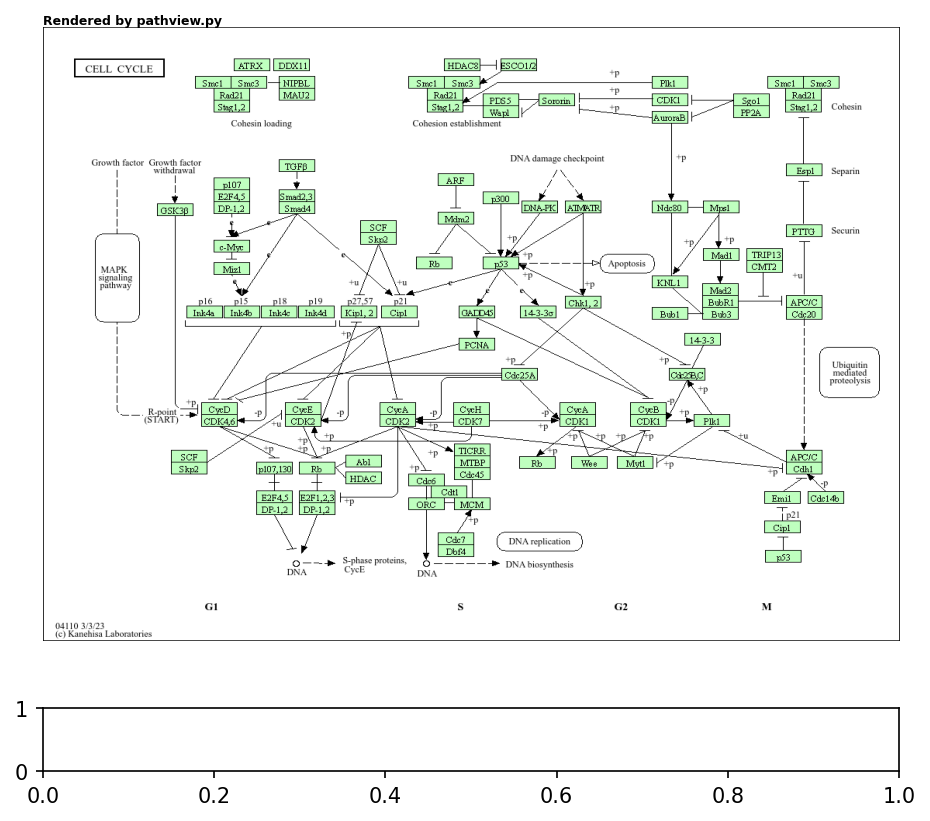

In [76]:
from IPython.display import Image, display

cell_cycle_png = pathview_dir / "hsa04110.normal_vs_primary_cell_cycle.png"

print("Does output image exist?", cell_cycle_png.exists())
print("Output image path:", cell_cycle_png)

display(Image(filename=str(cell_cycle_png)))

In [77]:
print("Pathview output files:")

for file in sorted(pathview_dir.glob("*")):
    print(file.name)

Pathview output files:
hsa04110.normal_vs_primary_cell_cycle.png
hsa04110.png
hsa04110.xml


## First Pathview Plus figure check

Pathview Plus successfully rendered the KEGG cell cycle pathway image.

However, the figure looks like the base KEGG pathway map rather than a fully data-colored expression map. The earlier output also returned `plot_data_gene: None`, which suggests that my gene-level values may not have mapped onto the pathway nodes.

This is likely a gene identifier issue. My expression table uses gene symbols, but KEGG pathway mapping often works more reliably with Entrez IDs. My next step is to test Entrez ID conversion and rerun Pathview Plus using `gene_idtype="ENTREZ"`.

In [78]:
!pip install -q mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00


In [79]:
import mygene
import pandas as pd
import polars as pl

mg = mygene.MyGeneInfo()

# Start from the simple Pathview input
pathview_input_pd = pathview_simple_input.to_pandas()
pathview_input_pd = pathview_input_pd.dropna(subset=["gene_id", "value"])

gene_symbols = pathview_input_pd["gene_id"].astype(str).unique().tolist()

print("Number of gene symbols to map:", len(gene_symbols))

query_results = mg.querymany(
    gene_symbols,
    scopes="symbol",
    fields="entrezgene,symbol",
    species="human",
    as_dataframe=False
)

mapping_rows = []

for result in query_results:
    if "notfound" in result and result["notfound"]:
        continue

    if "entrezgene" in result:
        mapping_rows.append({
            "gene_id": result["query"],
            "symbol": result.get("symbol", result["query"]),
            "entrez_id": str(result["entrezgene"])
        })

gene_mapping = pd.DataFrame(mapping_rows)

display(gene_mapping.head())
print("Mapped genes:", gene_mapping.shape[0])

INFO:biothings.client:querying 1-1000 ...


Number of gene symbols to map: 23503


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 21001-22000 ...
INFO:biothings.client:querying

,gene_id,symbol,entrez_id
0,OPN1MW2,OPN1MW2,728458
1,MORF4L1,MORF4L1,10933
2,TTTY7,TTTY7,246122
3,CTRL,CTRL,1506
4,INTU,INTU,27152


Mapped genes: 20127


In [80]:
pathview_entrez_pd = pathview_input_pd.merge(
    gene_mapping[["gene_id", "entrez_id"]],
    on="gene_id",
    how="inner"
)

pathview_entrez_pd = pathview_entrez_pd[["entrez_id", "value"]].dropna()

# If duplicate Entrez IDs exist, average them
pathview_entrez_pd = (
    pathview_entrez_pd
    .groupby("entrez_id", as_index=False)
    .agg({"value": "mean"})
)

display(pathview_entrez_pd.head())
print("Entrez Pathview input shape:", pathview_entrez_pd.shape)

,entrez_id,value
0,1,-0.376828
1,10,-6.118258
2,100,1.079107
3,1000,0.137400
4,10000,0.345698


Entrez Pathview input shape: (20127, 2)


## Entrez ID mapping note

I converted gene symbols to Entrez IDs because the first Pathview Plus figure rendered, but the gene values did not appear to map onto the KEGG pathway nodes.

Since KEGG pathways commonly use Entrez style gene identifiers, this Entrez based input should be a better match for Pathview Plus.

In [81]:
gene_data_entrez_for_pathview = pl.from_pandas(pathview_entrez_pd)

display(gene_data_entrez_for_pathview.head())
print(gene_data_entrez_for_pathview.shape)
print(gene_data_entrez_for_pathview.columns)

entrez_id,value
str,f64
"""1""",-0.376828
"""10""",-6.118258
"""100""",1.079107
"""1000""",0.1373995
"""10000""",0.345698


(20127, 2)
['entrez_id', 'value']


In [82]:
cell_cycle_result_entrez = pathview.pathview(
    pathway_id="hsa04110",
    gene_data=gene_data_entrez_for_pathview,
    species="hsa",
    kegg_dir=pathview_dir,
    kegg_native=True,
    output_format="png",
    gene_idtype="ENTREZ",
    out_suffix="normal_vs_primary_cell_cycle_entrez",
    map_symbol=True
)

print("Pathview Plus Entrez run complete")
print(cell_cycle_result_entrez)

Note: 19925 of 20127 input IDs unmapped.
Info: Written → gse50760_pygage/results/pathview_outputs/hsa04110.normal_vs_primary_cell_cycle_entrez.png
Pathview Plus Entrez run complete
{'plot_data_gene': shape: (112, 14)
┌──────────┬──────────────────────┬──────┬───────┬───┬──────────┬───────────┬──────┬────────────┐
│ entry_id ┆ name                 ┆ type ┆ x     ┆ … ┆ reaction ┆ component ┆ size ┆ value      │
│ ---      ┆ ---                  ┆ ---  ┆ ---   ┆   ┆ ---      ┆ ---       ┆ ---  ┆ ---        │
│ str      ┆ str                  ┆ str  ┆ f64   ┆   ┆ str      ┆ str       ┆ i64  ┆ f64        │
╞══════════╪══════════════════════╪══════╪═══════╪═══╪══════════╪═══════════╪══════╪════════════╡
│ 4        ┆ hsa:1029             ┆ gene ┆ 532.0 ┆ … ┆          ┆           ┆ 1    ┆ 1.611514   │
│ 5        ┆ hsa:51343            ┆ gene ┆ 981.0 ┆ … ┆          ┆           ┆ 1    ┆ 1.151457   │
│ 6        ┆ hsa:4171 hsa:4172    ┆ gene ┆ 553.0 ┆ … ┆          ┆           ┆ 1    ┆ 71.276923  │

/usr/local/lib/python3.12/dist-packages/pathview/pathview.py:315: UserWarning: Symbol label mapping failed: "kegg_names" not found
  warnings.warn(f"Symbol label mapping failed: {exc}")


Does Entrez output image exist? True
Output image path: gse50760_pygage/results/pathview_outputs/hsa04110.normal_vs_primary_cell_cycle_entrez.png


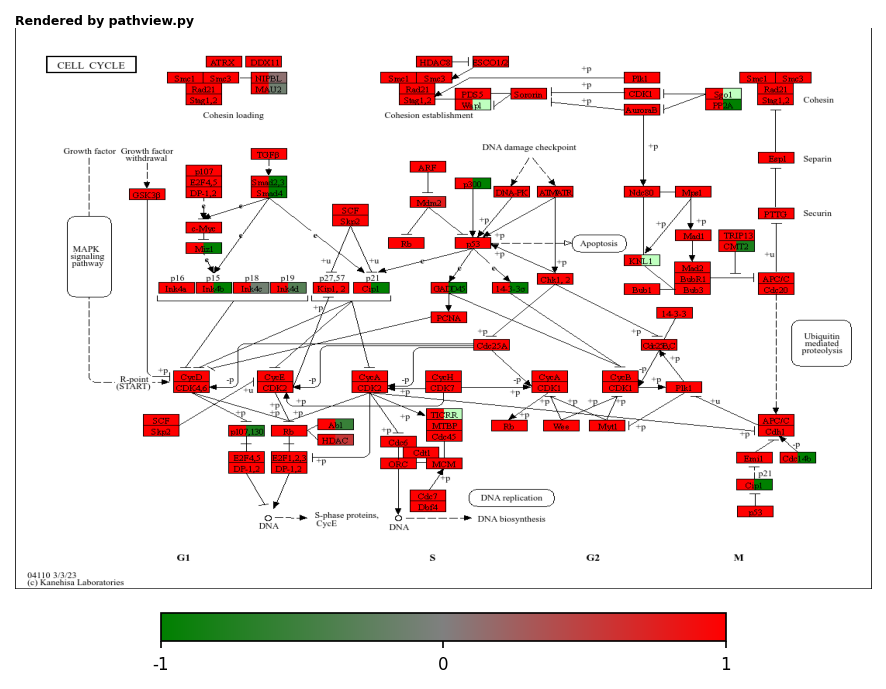

In [83]:
from IPython.display import Image, display

cell_cycle_entrez_png = pathview_dir / "hsa04110.normal_vs_primary_cell_cycle_entrez.png"

print("Does Entrez output image exist?", cell_cycle_entrez_png.exists())
print("Output image path:", cell_cycle_entrez_png)

display(Image(filename=str(cell_cycle_entrez_png)))

## Cell cycle visualization interpretation

The KEGG cell cycle pathway was chosen because the pyGAGE normal colon versus primary colorectal cancer comparison showed cell cycle/proliferation as one of the strongest positive pathway signals.

The Pathview Plus figure provides a visual check of where gene level changes appear on the pathway map. I would not treat the figure alone as proof of pathway activation, but it helps connect the pathway level pyGAGE result back to the underlying genes and their positions in the pathway.

## Entrez based Pathview Plus result note

The Entrez based Pathview Plus run worked.

The earlier symbol based attempt generated a pathway image, but the gene level values did not map onto the KEGG pathway nodes. After converting gene symbols to Entrez IDs and rerunning Pathview Plus with `gene_idtype="ENTREZ"`, the pathway map shows red and green coloring across the cell cycle pathway.

This confirms that the issue was gene identifier mapping, not the Pathview Plus rendering step itself.

For this walkthrough, this is an important lesson: pyGAGE can use gene symbols for the gene set test, but Pathview Plus mapping to KEGG pathways works better when the gene level input uses Entrez IDs.

In [85]:
ecm_result_entrez = pathview.pathview(
    pathway_id="hsa04512",
    gene_data=gene_data_entrez_for_pathview,
    species="hsa",
    kegg_dir=pathview_dir,
    kegg_native=True,
    output_format="png",
    gene_idtype="ENTREZ",
    out_suffix="normal_vs_primary_ecm_receptor_entrez",
    map_symbol=True
)

print("ECM receptor interaction Pathview Plus run complete")
print(ecm_result_entrez)

Info: Downloading xml for hsa04512 …
Info: Downloading png for hsa04512 …
Note: 19681 of 20127 input IDs unmapped.
Info: Written → gse50760_pygage/results/pathview_outputs/hsa04512.normal_vs_primary_ecm_receptor_entrez.png
ECM receptor interaction Pathview Plus run complete
{'plot_data_gene': shape: (122, 14)
┌──────────┬─────────────────────┬──────┬───────┬───┬──────────┬───────────┬──────┬───────────┐
│ entry_id ┆ name                ┆ type ┆ x     ┆ … ┆ reaction ┆ component ┆ size ┆ value     │
│ ---      ┆ ---                 ┆ ---  ┆ ---   ┆   ┆ ---      ┆ ---       ┆ ---  ┆ ---       │
│ str      ┆ str                 ┆ str  ┆ f64   ┆   ┆ str      ┆ str       ┆ i64  ┆ f64       │
╞══════════╪═════════════════════╪══════╪═══════╪═══╪══════════╪═══════════╪══════╪═══════════╡
│ 26       ┆ hsa:10319 hsa:22798 ┆ gene ┆ 714.0 ┆ … ┆          ┆           ┆ 1    ┆ 27.430972 │
│          ┆ hsa:284217…         ┆      ┆       ┆   ┆          ┆           ┆      ┆           │
│ 27       ┆ hsa:

/usr/local/lib/python3.12/dist-packages/pathview/pathview.py:315: UserWarning: Symbol label mapping failed: "kegg_names" not found
  warnings.warn(f"Symbol label mapping failed: {exc}")


Does ECM output image exist? True
Output image path: gse50760_pygage/results/pathview_outputs/hsa04512.normal_vs_primary_ecm_receptor_entrez.png


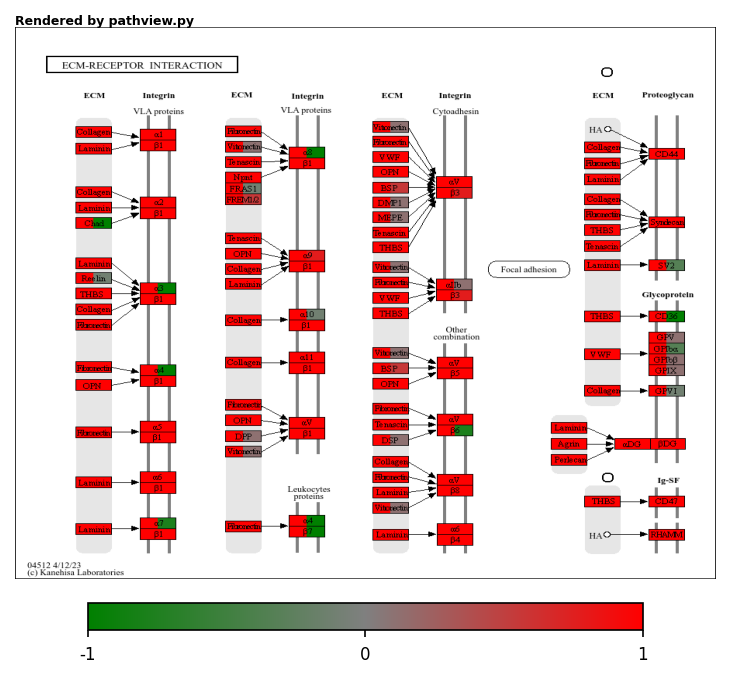

In [86]:
ecm_entrez_png = pathview_dir / "hsa04512.normal_vs_primary_ecm_receptor_entrez.png"

print("Does ECM output image exist?", ecm_entrez_png.exists())
print("Output image path:", ecm_entrez_png)

display(Image(filename=str(ecm_entrez_png)))

## ECM receptor interaction Pathview Plus note

I also tested the KEGG ECM receptor interaction pathway because the custom ECM/invasion/metastasis gene set was one of the significant positive pyGAGE signals in primary colorectal cancer compared with normal colon.

This gives a second Pathview Plus example connected to the pyGAGE result. Together, the cell cycle and ECM pathway maps show how the workflow can move from pathway statistics to visual pathway context.

In [87]:
import shutil
from pathlib import Path
from google.colab import files

folder_to_zip = Path("gse50760_pygage")
zip_name = "gse50760_pygage_work_so_far"

shutil.make_archive(zip_name, "zip", folder_to_zip)

print("Created zip file:", zip_name + ".zip")

Created zip file: gse50760_pygage_work_so_far.zip


In [88]:
files.download("gse50760_pygage_work_so_far.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>